<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/weightManifoldDistillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 this experiment is motivated by observing teacher-student output distillation where we conclude the shape of the output contains some structure that the student picks up on as is witnessed in "owl" random number experimenting. At which point we ask- why not skip the middleman and attempt to distill the structure? This of course is a complex problem. It involves a banach space contraction between a source manifold of rank(whatever higher rank the larger model can accomodate happily) to a target manifold of rank(whatever the smaller model can accomodate). Some detail must be lost.

 Two key points: the larger manifold doesnt actually * need* to be fully trained. recent experiments- ie "squeeze evolve paper" demonstrate this.
 It rather needs to pick up the "shape" of the problem. Extra space means that the shape can be better "witnessed". this shape is what we aim to distill. The fine tuning on detail, or bulk learning, happens in a smaller model.

 We can even see this possibility- smaller models -> larger models USUALLY underperform large->small. But what about large->small->large?

 The idea is- the small model has big model smell and structure, and when we inflate it, we actually are adding back the room for details to a manifold that was bigger to begin with, which has been tweaked to just the right shape in the smaller model.

 at present- nobody has accomplished this particular idea. people are all dancing around it, but since nobody actually can, in practice, decompose the geometry, they cannot also create good lower ranked forms. Yes- on known structure, SVD works. but real model manifolds are noisy. SVD immediately becomes degenerate, and frankly an ordinary household can achieve better results(as witnessed here, where a procrustes modified form fails). SVD can only tell us what the optimal representation is. it cannot tell us how to get there on real noisy linear parameters.

 If you can solve this problem,proof of your solution is trivial-
 your student model in the below experiment starts at a lower loss than the untrained one, and winds up at a lower loss.




In [14]:
"""
CardHouse Optimizer
===================

A drop-in PyTorch optimizer that replaces Newton-Muon's Cholesky-based
right-preconditioning with a Householder direction decomposition using
MAD-based (robust) scale estimation.

For matrix-shaped parameters (2D), CardHouse:
  1. Maintains k learned Householder vectors per parameter that track
     the top eigenvectors of the input activation second moment ZZ^T
     via deflated power iteration.
  2. Estimates per-direction scale using median absolute deviation (MAD)
     converted to Gaussian-equivalent sigma, which is robust to the
     heavy-tailed distributions produced by GELU/ReLU activations.
  3. Preconditions the gradient by rescaling its components along each
     Householder direction to equalize their robust scales.
  4. Applies the matrix sign (via Newton-Schulz iteration) to the
     preconditioned gradient.
  5. Updates with momentum.

For 1D parameters (biases, norms), falls back to momentum SGD.

What register_activations does: Attaches forward hooks to every nn.Linear. Each hook captures the input tensor, reshapes it to (dim, batch*seq), and stashes it. On optimizer.step(), CardHouse reads these buffers to update its Householder directions and scale estimates. If you don't call it, the optimizer falls back to using the gradient's column structure as a proxy, which is worse but functional.
What split_params does: Walks named_parameters, puts 2D tensors into the matrix bucket (CardHouse), everything else into scalar bucket (AdamW). Embeddings get heuristically detected by aspect ratio (first dim > 10x second dim) and routed to AdamW.
The k parameter: Number of Householder vectors. Start with k=8. For models where d_model is large and anisotropy is concentrated in a few directions (which the paper's Table 4 suggests is typical), k=8-16 should capture most of it. k=3 matching your spike count is the theoretical minimum for this synthetic data.
diagnostics() returns per-parameter scale info. The mean_ratio field (var_scale / robust_scale) tells you how non-Gaussian each direction is. Ratio near 1.0 means Gaussian, above 1.0 means heavy tails where the MAD estimator is earning its keep.
Call remove_hooks() when done training, or the hooks hold references to the model and leak memory.

Usage
-----
    from cardhouse import CardHouse

    optimizer = CardHouse(model.parameters(), lr=0.01)

    for batch in dataloader:
        loss = model(batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

With activation hooks (recommended for best results):
    optimizer = CardHouse(model.parameters(), lr=0.01)
    optimizer.register_activations(model)  # auto-hooks linear layers

    for batch in dataloader:
        loss = model(batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

Without hooks, CardHouse still works but cannot track activation
statistics. It will precondition using only the gradient's own
column structure as a proxy for input anisotropy.
"""

import torch
import torch.nn as nn
from torch.optim import Optimizer
import math
from typing import Optional, List, Dict, Any


def _msgn_ns(G: torch.Tensor, steps: int = 10) -> torch.Tensor:
    """
    Matrix sign via Newton-Schulz iteration.
    X_{k+1} = 1.5 X_k - 0.5 X_k X_k^T X_k

    Input:  G of shape (m, n)
    Output: U V^T where G = U S V^T (compact SVD), shape (m, n)
    """
    norm = torch.norm(G, p="fro")
    if norm < 1e-12:
        return G
    X = G / norm
    for _ in range(steps):
        XXT = X @ X.T
        X = 1.5 * X - 0.5 * (XXT @ X)
    return X


def _robust_scale(projections: torch.Tensor) -> torch.Tensor:
    """
    MAD-based robust scale estimation.
    Returns Gaussian-equivalent variance: (MAD / 0.6745)^2

    projections: (batch,) tensor of scalar projections
    """
    median = projections.median()
    abs_dev = (projections - median).abs()
    mad = abs_dev.median()
    sigma = mad / 0.6745
    return sigma * sigma


class _HouseholderState:
    """Per-parameter Householder direction state."""

    def __init__(self, n: int, k: int, device: torch.device, dtype: torch.dtype):
        self.k = k
        self.n = n
        # initialize with random orthogonal-ish directions
        vs = torch.randn(k, n, device=device, dtype=dtype)
        # QR to get orthonormal initial directions
        if k <= n:
            q, _ = torch.linalg.qr(vs.T)
            self.vs = q.T[:k].contiguous()  # (k, n)
        else:
            self.vs = torch.nn.functional.normalize(vs, dim=1)
        self.robust_scales = torch.ones(k, device=device, dtype=dtype)
        self.var_scales = torch.ones(k, device=device, dtype=dtype)
        self.initialized = False

    def update_from_activations(
        self, Z: torch.Tensor, beta: float, blend: float = 0.3
    ):
        """
        Update directions and scales from activation matrix.
        Z: (n, batch) or (batch, n) - will be handled.
        """
        if Z.shape[0] != self.n:
            if Z.shape[1] == self.n:
                Z = Z.T
            else:
                return  # shape mismatch, skip

        batch = Z.shape[1]
        if batch < 4:
            return

        with torch.no_grad():
            for i in range(self.k):
                v = self.vs[i]  # (n,)

                # project activations onto direction
                projs = Z.T @ v  # (batch,)

                # variance scale
                var = projs.var().clamp(min=1e-12)
                if self.initialized:
                    self.var_scales[i] = beta * self.var_scales[i] + (1 - beta) * var
                else:
                    self.var_scales[i] = var

                # robust scale (MAD)
                rs = _robust_scale(projs).clamp(min=1e-12)
                if self.initialized:
                    self.robust_scales[i] = (
                        beta * self.robust_scales[i] + (1 - beta) * rs
                    )
                else:
                    self.robust_scales[i] = rs

                # power iteration step: rotate toward top eigenvector of ZZ^T
                # ZZ^T v = Z (Z^T v) = Z projs
                ZZTv = (Z * projs.unsqueeze(0)).sum(dim=1) / batch  # (n,)

                # deflate against previous directions
                for p in range(i):
                    dot = ZZTv @ self.vs[p]
                    ZZTv = ZZTv - dot * self.vs[p]

                norm = ZZTv.norm()
                if norm > 1e-10:
                    new_v = (1 - blend) * v + blend * (ZZTv / norm)
                    self.vs[i] = torch.nn.functional.normalize(new_v, dim=0)

            self.initialized = True

    def update_from_gradient(self, G: torch.Tensor, beta: float, blend: float = 0.3):
        """
        Fallback: use gradient column structure as proxy for activation anisotropy.
        G: (m, n) gradient matrix. We treat columns of G^T as samples.
        """
        # G^T G / m approximates input second moment structure
        Z = G.T  # (n, m) - treat the m rows of G as "samples"
        self.update_from_activations(Z, beta, blend)

    def precondition(self, G: torch.Tensor) -> torch.Tensor:
        """
        Right-precondition gradient G of shape (m, n) using Householder directions.
        Rescales gradient components along each direction by ratio of
        mean robust scale to per-direction robust scale.
        """
        if not self.initialized:
            return G

        mean_scale = self.robust_scales.mean()
        if mean_scale < 1e-12:
            return G

        Gout = G.clone()
        for i in range(self.k):
            v = self.vs[i]  # (n,)
            rescale = mean_scale / (self.robust_scales[i] + 1e-8)

            # Gout[row, :] += (Gout[row, :] . v) * (rescale - 1) * v
            dots = Gout @ v  # (m,)
            Gout = Gout + (rescale - 1.0) * dots.unsqueeze(1) * v.unsqueeze(0)

        return Gout


class CardHouse(Optimizer):
    """
    CardHouse optimizer.

    Args:
        params: iterable of parameters or param groups
        lr: learning rate (default: 0.01)
        momentum: momentum coefficient (default: 0.85)
        k: number of Householder vectors per matrix parameter (default: 8)
        beta: EWMA coefficient for scale tracking (default: 0.95)
        ns_steps: Newton-Schulz iterations for matrix sign (default: 10)
        refresh_every: update Householder directions every N steps (default: 4)
        blend: power iteration blending factor (default: 0.3)
        weight_decay: weight decay coefficient (default: 0.0)
        scalar_lr_scale: learning rate multiplier for 1D params (default: 0.3)
        matrix_threshold: minimum dimension to treat as matrix param (default: 2)
    """

    def __init__(
        self,
        params,
        lr: float = 0.01,
        momentum: float = 0.85,
        k: int = 8,
        beta: float = 0.95,
        ns_steps: int = 10,
        refresh_every: int = 4,
        blend: float = 0.3,
        weight_decay: float = 0.0,
        scalar_lr_scale: float = 0.3,
        matrix_threshold: int = 2,
    ):
        defaults = dict(
            lr=lr,
            momentum=momentum,
            k=k,
            beta=beta,
            ns_steps=ns_steps,
            refresh_every=refresh_every,
            blend=blend,
            weight_decay=weight_decay,
            scalar_lr_scale=scalar_lr_scale,
            matrix_threshold=matrix_threshold,
        )
        super().__init__(params, defaults)
        self._step_count = 0
        self._activation_buffers: Dict[nn.Module, torch.Tensor] = {}
        self._param_to_module: Dict[nn.Parameter, nn.Module] = {}
        self._hooks: List[Any] = []

    def register_activations(self, model: nn.Module):
        """
        Register forward hooks on all Linear layers to capture input activations.
        Call once before training.
        """
        for module in model.modules():
            if isinstance(module, nn.Linear):
                # map parameter to module
                self._param_to_module[module.weight] = module
                if module.bias is not None:
                    self._param_to_module[module.bias] = module

                handle = module.register_forward_hook(self._activation_hook)
                self._hooks.append(handle)

    def _activation_hook(self, module: nn.Module, input, output):
        """Capture input activations for a linear layer."""
        if not module.training:
          return
        x = input[0]
        if x.dim() == 3:
            # (batch, seq, dim) -> flatten to (batch*seq, dim)
            x = x.reshape(-1, x.shape[-1])
        elif x.dim() == 1:
            x = x.unsqueeze(0)
        # store as (dim, samples) for consistency with ZZ^T convention
        self._activation_buffers[module] = x.T.detach()

    def remove_hooks(self):
        """Remove all registered hooks."""
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

    def _get_house_state(
        self, p: torch.Tensor, group: dict
    ) -> Optional[_HouseholderState]:
        """Get or create Householder state for a parameter."""
        state = self.state[p]
        if "house" not in state:
            if p.dim() != 2:
                return None
            m, n = p.shape
            if min(m, n) < group["matrix_threshold"]:
                return None
            effective_k = min(group["k"], n)
            state["house"] = _HouseholderState(n, effective_k, p.device, p.dtype)
        return state["house"]

    @torch.no_grad()
    def step(self, closure=None):
        """Perform a single optimization step."""
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        self._step_count += 1

        for group in self.param_groups:
            lr = group["lr"]
            mom = group["momentum"]
            beta = group["beta"]
            ns_steps = group["ns_steps"]
            wd = group["weight_decay"]
            refresh = group["refresh_every"]
            blend = group["blend"]
            scalar_lr = lr * group["scalar_lr_scale"]
            do_refresh = (self._step_count % refresh == 0) or (self._step_count == 1)

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad

                # weight decay
                if wd != 0:
                    grad = grad.add(p.data, alpha=wd)

                # initialize momentum buffer
                state = self.state[p]
                if "momentum_buffer" not in state:
                    state["momentum_buffer"] = torch.zeros_like(p.data)

                buf = state["momentum_buffer"]

                if p.dim() == 2 and min(p.shape) >= group["matrix_threshold"]:
                    # matrix parameter: CardHouse update
                    house = self._get_house_state(p, group)

                    if house is not None and do_refresh:
                        # try to get activations from hook
                        module = self._param_to_module.get(p)
                        if module is not None and module in self._activation_buffers:
                            Z = self._activation_buffers[module]
                            house.update_from_activations(Z, beta, blend)
                        else:
                            # fallback: use gradient structure
                            house.update_from_gradient(grad, beta, blend)

                    if house is not None:
                        G_precond = house.precondition(grad)
                    else:
                        G_precond = grad

                    Q = _msgn_ns(G_precond, steps=ns_steps)

                    buf.mul_(mom).add_(Q)
                    p.data.add_(buf, alpha=-lr)

                else:
                    # scalar/1D parameter: momentum SGD
                    buf.mul_(mom).add_(grad)
                    p.data.add_(buf, alpha=-scalar_lr)

        # clear activation buffers after step
        self._activation_buffers.clear()

        return loss

    def diagnostics(self) -> dict:
        """
        Return diagnostic information about Householder states.
        Useful for logging during training.

        Returns dict with per-parameter info:
            - robust_scales: MAD-based scales per direction
            - var_scales: variance-based scales per direction
            - scale_ratio: var/robust per direction (>1 means heavy tails)
            - directions: the Householder vectors
        """
        info = {}
        for group in self.param_groups:
            for i, p in enumerate(group["params"]):
                state = self.state.get(p, {})
                house = state.get("house")
                if house is not None and house.initialized:
                    ratio = house.var_scales / (house.robust_scales + 1e-12)
                    info[f"param_{i}"] = {
                        "shape": tuple(p.shape),
                        "robust_scales": house.robust_scales.clone(),
                        "var_scales": house.var_scales.clone(),
                        "scale_ratio": ratio,
                        "mean_ratio": ratio.mean().item(),
                        "k": house.k,
                    }
        return info


class CardHouseAdamW(Optimizer):
    """
    Hybrid optimizer: CardHouse for 2D (matrix) parameters,
    AdamW for everything else.

    This is the recommended configuration for transformer training,
    matching the pattern used by Muon/Newton-Muon papers where
    matrix params get the spectral optimizer and embed/norm/bias
    params get Adam.

    Args:
        matrix_params: iterable of 2D parameters (Linear weights)
        scalar_params: iterable of other parameters (biases, norms, embeddings)
        matrix_lr: learning rate for matrix params (default: 0.01)
        scalar_lr: learning rate for scalar params (default: 3e-4)
        k: Householder vectors (default: 8)
        momentum: for CardHouse (default: 0.85)
        betas: for AdamW (default: (0.9, 0.999))
        weight_decay: for AdamW (default: 0.01)
        **cardhouse_kwargs: additional kwargs passed to CardHouse
    """

    def __init__(
        self,
        matrix_params,
        scalar_params,
        matrix_lr: float = 0.01,
        scalar_lr: float = 3e-4,
        k: int = 8,
        momentum: float = 0.85,
        betas=(0.9, 0.999),
        weight_decay: float = 0.01,
        **cardhouse_kwargs,
    ):
        matrix_params = list(matrix_params)
        scalar_params = list(scalar_params)

        self.cardhouse = CardHouse(
            matrix_params, lr=matrix_lr, momentum=momentum, k=k, **cardhouse_kwargs
        )
        self.adamw = torch.optim.AdamW(
            scalar_params, lr=scalar_lr, betas=betas, weight_decay=weight_decay
        )

        # expose param_groups for schedulers
        self.param_groups = self.cardhouse.param_groups + self.adamw.param_groups
        self.state = {}

    def register_activations(self, model: nn.Module):
        self.cardhouse.register_activations(model)

    def remove_hooks(self):
        self.cardhouse.remove_hooks()

    def zero_grad(self, set_to_none=True):
        self.cardhouse.zero_grad(set_to_none=set_to_none)
        self.adamw.zero_grad(set_to_none=set_to_none)

    @torch.no_grad()
    def step(self, closure=None):
        loss = self.cardhouse.step(closure)
        self.adamw.step()
        return loss

    def diagnostics(self):
        return self.cardhouse.diagnostics()

    def state_dict(self):
        return {
            "cardhouse": self.cardhouse.state_dict(),
            "adamw": self.adamw.state_dict(),
        }

    def load_state_dict(self, state_dict):
        self.cardhouse.load_state_dict(state_dict["cardhouse"])
        self.adamw.load_state_dict(state_dict["adamw"])


def split_params(model: nn.Module):
    """
    Split model parameters into matrix params (for CardHouse)
    and scalar params (for AdamW).

    Returns (matrix_params, scalar_params) as lists.

    Convention: any 2D parameter with both dims >= 2 is a matrix param.
    Everything else (embeddings, biases, layernorm weights) is scalar.
    """
    matrix_params = []
    scalar_params = []
    seen = set()

    for name, p in model.named_parameters():
        if id(p) in seen:
            continue
        seen.add(id(p))

        if p.dim() == 2 and min(p.shape) >= 2:
            # skip embeddings: typically (vocab, dim) with very large first dim
            # heuristic: if first dim > 10x second dim, treat as embedding
            if p.shape[0] > 10 * p.shape[1]:
                scalar_params.append(p)
            else:
                matrix_params.append(p)
        else:
            scalar_params.append(p)

    return matrix_params, scalar_params


"""
Manifold Geometry Distillation Experiment
==========================================

Tests whether compressing a trained model's learned manifold geometry
into a smaller architecture produces qualitatively different internal
structure than training the smaller architecture from scratch.

Setup:
  - Fractal two-spiral classification (4 levels of recursive bumps)
  - Teacher: embed(2)->linear(2*8=16)->gelu->linear(16->8)->unembed(8->num_classes)
  - Student: embed(2)->linear(2*2=4)->gelu->linear(4->2)->unembed(2->num_classes)
  - Distilled student: initialized from CardHouse decomposition of teacher manifold
  - Vanilla student: trained from random init

Analysis:
  - Weight matrix SVD spectra (anisotropy)
  - Effective rank
  - Jacobian structure at test points
  - Decision boundary resolution at each fractal scale
  - CardHouse diagnostics (robust vs variance scales)

Requires: torch, numpy, matplotlib, cardhouse.py in same directory
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import copy


# ============================================================
# 1. FRACTAL SPIRAL DATA GENERATION
# ============================================================

def make_fractal_spiral(n_points=2000, noise=0.02, n_recursions=4, seed=42):
    """
    Generate a two-spiral dataset with fractal bumps.

    Each spiral has recursive bumps at decreasing scales along its curve.
    This creates a hierarchy of rare sub-classes: points near bump peaks
    at recursion level k are rarer than those at level k-1.

    Returns:
        X: (2*n_points, 2) coordinates
        y: (2*n_points,) binary labels
        level_labels: (2*n_points,) which recursion level dominates each point
    """
    rng = np.random.RandomState(seed)

    def spiral_with_bumps(t, n_recursions, base_radius=1.0):
        """
        Compute spiral coordinates with fractal bumps.
        t: parameter in [0, 1] along the spiral
        """
        # base spiral: 2 full turns
        theta = t * 4 * np.pi
        r = base_radius * (0.3 + t * 0.7)  # radius grows with t

        # add fractal bumps to the radius
        bump_r = np.zeros_like(t)
        dominant_level = np.zeros_like(t, dtype=int)

        for level in range(n_recursions):
            freq = 3 * (3 ** level)  # 3, 9, 27, 81 bumps
            amplitude = 0.03 * (0.4 ** level)  # decreasing amplitude
            bump = amplitude * np.sin(freq * t * 2 * np.pi)
            bump_r += bump

            # track which level dominates each point
            # a point is "near a bump peak" at this level if the sine is large
            peak_mask = np.abs(np.sin(freq * t * 2 * np.pi)) > 0.8
            dominant_level[peak_mask] = level + 1

        r = r + bump_r
        x = r * np.cos(theta)
        y_coord = r * np.sin(theta)

        return x, y_coord, dominant_level

    t = np.linspace(0, 1, n_points)

    # spiral 1
    x1, y1, levels1 = spiral_with_bumps(t, n_recursions)
    # spiral 2: rotated 180 degrees
    x2, y2, levels2 = spiral_with_bumps(t, n_recursions)
    x2, y2 = -x2, -y2

    # add noise
    x1 += rng.randn(n_points) * noise
    y1 += rng.randn(n_points) * noise
    x2 += rng.randn(n_points) * noise
    y2 += rng.randn(n_points) * noise

    X = np.vstack([
        np.column_stack([x1, y1]),
        np.column_stack([x2, y2])
    ]).astype(np.float32)

    y = np.hstack([
        np.zeros(n_points, dtype=np.int64),
        np.ones(n_points, dtype=np.int64)
    ])

    level_labels = np.hstack([levels1, levels2])

    return X, y, level_labels


# ============================================================
# 2. MODEL DEFINITION
# ============================================================

class SpiralNet(nn.Module):
    """
    Simple MLP: embed -> linear(2*width) -> gelu -> linear(width) -> unembed

    Args:
        width: hidden dimension multiplier
        input_dim: input features (2 for spiral)
        num_classes: output classes (2 for binary)
    """
    def __init__(self, width=8, input_dim=2, num_classes=2):
        super().__init__()
        self.width = width
        hidden = 2 * width

        self.embed = nn.Linear(input_dim, hidden, bias=True)
        self.up = nn.Linear(hidden, hidden, bias=True)
        self.down = nn.Linear(hidden, width, bias=True)
        self.unembed = nn.Linear(width, num_classes, bias=True)

    def forward(self, x):
        x = self.embed(x)
        x = F.gelu(x)
        x = self.up(x)
        x = F.gelu(x)
        x = self.down(x)
        x = F.gelu(x)
        x = self.unembed(x)
        return x

    def get_latent(self, x):
        """Return the representation after the down projection (before unembed)."""
        x = self.embed(x)
        x = F.gelu(x)
        x = self.up(x)
        x = F.gelu(x)
        x = self.down(x)
        return x


# ============================================================
# 3. TRAINING
# ============================================================

def train_model(model, X, y, lr=0.01, epochs=500, use_cardhouse=True,
                k=8, print_every=50, grok_detect=True):
    """
    Train a SpiralNet.

    If grok_detect=True, monitors for the grokking transition
    (sharp drop in loss after plateau) and returns extra info.

    Returns:
        model: trained model
        history: dict with loss, acc, and optionally cardhouse diagnostics per epoch
    """
    device = next(model.parameters()).device
    X_t = torch.tensor(X, device=device)
    y_t = torch.tensor(y, device=device)

    if use_cardhouse:
        optimizer = CardHouse(model.parameters(), lr=lr, k=k, momentum=0.85,
                              beta=0.95, ns_steps=10, refresh_every=4)
        optimizer.register_activations(model)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'loss': [], 'acc': [], 'diagnostics': []}
    grok_epoch = None
    prev_acc = 0.0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_t)
        loss = F.cross_entropy(logits, y_t)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            preds = logits.argmax(dim=1)
            acc = (preds == y_t).float().mean().item()

        history['loss'].append(loss.item())
        history['acc'].append(acc)

        if use_cardhouse and hasattr(optimizer, 'diagnostics'):
            history['diagnostics'].append(optimizer.diagnostics())

        # grokking detection: sharp accuracy jump
        if grok_detect and grok_epoch is None:
            if acc > 0.95 and prev_acc < 0.85:
                grok_epoch = epoch
                if print_every:
                    print(f"  Grokking detected at epoch {epoch}, acc={acc:.4f}")
        prev_acc = acc

        if print_every and (epoch % print_every == 0 or epoch == epochs - 1):
            print(f"  Epoch {epoch:4d}: loss={loss.item():.4f}, acc={acc:.4f}")

    if use_cardhouse:
        optimizer.remove_hooks()

    history['grok_epoch'] = grok_epoch
    return model, history


# ============================================================
# 4. CARDHOUSE-BASED MANIFOLD DECOMPOSITION AND COMPRESSION
# ============================================================

def extract_manifold_geometry(model, X, k=8):
    """
    Run a forward pass through the trained teacher model, capture activations,
    and compute CardHouse Householder decompositions at each linear layer.

    Returns a dict mapping layer_name -> {
        'householder_vectors': (k, n) tensor,  # top-k directions
        'robust_scales': (k,) tensor,           # MAD-based scales
        'var_scales': (k,) tensor,               # variance-based scales
        'weight': parameter tensor,
        'bias': parameter tensor or None,
        'activation_stats': dict with mean, std of activations
    }
    """
    device = next(model.parameters()).device
    X_t = torch.tensor(X, device=device)

    # set up activation capture
    activations = {}
    hooks = []

    def make_hook(name):
        def hook(module, input, output):
            x = input[0]
            if x.dim() == 3:
                x = x.reshape(-1, x.shape[-1])
            elif x.dim() == 1:
                x = x.unsqueeze(0)
            activations[name] = x.detach()
        return hook

    layer_map = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            hooks.append(module.register_forward_hook(make_hook(name)))
            layer_map[name] = module

    # forward pass to capture activations
    model.eval()
    with torch.no_grad():
        model(X_t)

    # remove hooks
    for h in hooks:
        h.remove()

    # build Householder decomposition for each layer
    geometry = {}
    for name, module in layer_map.items():
        W = module.weight.data  # (out, in)
        m, n = W.shape

        if min(m, n) < 2:
            continue

        effective_k = min(k, n)
        house = _HouseholderState(n, effective_k, device, W.dtype)

        if name in activations:
            Z = activations[name].T  # (dim, samples)
            # run multiple update passes to converge the directions
            for _ in range(20):
                house.update_from_activations(Z, beta=0.0, blend=0.8)

        act = activations.get(name)
        act_stats = {}
        if act is not None:
            act_stats['mean'] = act.mean(dim=0)
            act_stats['std'] = act.std(dim=0)
            act_stats['shape'] = act.shape

        geometry[name] = {
            'householder_vectors': house.vs.clone(),
            'robust_scales': house.robust_scales.clone(),
            'var_scales': house.var_scales.clone(),
            'weight': W.clone(),
            'bias': module.bias.data.clone() if module.bias is not None else None,
            'activation_stats': act_stats,
            'in_features': n,
            'out_features': m,
        }

    return geometry


def compress_manifold(geometry, target_width, source_width):
    """
    Compress teacher manifold geometry into student-sized weight matrices.

    For each layer, we:
    1. Use the Householder vectors (sorted by robust scale) as the basis
       defining the manifold's important directions.
    2. Build a projection matrix P that maps from source-dim to target-dim
       by keeping the top target_dim directions.
    3. Project the weight matrix: W_student = W_teacher @ P^T (right-project
       for input reduction) or P @ W_teacher (left-project for output reduction).

    The key insight: the Householder directions are ordered by how much
    activation variance flows through them. Dropping the bottom directions
    drops the least-used dimensions of the manifold.

    Args:
        geometry: output of extract_manifold_geometry
        target_width: student width
        source_width: teacher width

    Returns:
        compressed_weights: dict mapping layer_name -> {'weight': tensor, 'bias': tensor}
    """
    target_hidden = 2 * target_width
    source_hidden = 2 * source_width

    compressed = {}

    # layer dimension expectations for SpiralNet:
    # embed:   (source_hidden, 2)     -> (target_hidden, 2)
    # up:      (source_hidden, source_hidden) -> (target_hidden, target_hidden)
    # down:    (source_width, source_hidden) -> (target_width, target_hidden)
    # unembed: (2, source_width)      -> (2, target_width)

    dim_map = {
        'embed':   {'in': 2, 'out_src': source_hidden, 'out_tgt': target_hidden},
        'up':      {'in_src': source_hidden, 'in_tgt': target_hidden,
                    'out_src': source_hidden, 'out_tgt': target_hidden},
        'down':    {'in_src': source_hidden, 'in_tgt': target_hidden,
                    'out_src': source_width, 'out_tgt': target_width},
        'unembed': {'in_src': source_width, 'in_tgt': target_width, 'out': 2},
    }

    for layer_name, geo in geometry.items():
        W = geo['weight']  # (out, in)
        m, n = W.shape
        info = dim_map.get(layer_name, {})

        # determine which dimensions to compress
        needs_input_compress = info.get('in_src') is not None
        needs_output_compress = info.get('out_src') is not None and info.get('out_src') != info.get('out_tgt')

        W_new = W.clone()
        bias_new = geo['bias'].clone() if geo['bias'] is not None else None

        if needs_input_compress:
            # compress input dimension using Householder directions
            in_src = info['in_src']
            in_tgt = info['in_tgt']

            vecs = geo['householder_vectors']  # (k, in_src)
            scales = geo['robust_scales']

            # sort by scale (descending) and take top in_tgt
            sorted_idx = scales.argsort(descending=True)

            if vecs.shape[0] >= in_tgt and vecs.shape[1] == in_src:
                # build projection: take top in_tgt Householder directions
                P_in = vecs[sorted_idx[:in_tgt]]  # (in_tgt, in_src)

                # orthonormalize
                Q, _ = torch.linalg.qr(P_in.T)
                P_in = Q.T[:in_tgt]  # (in_tgt, in_src)

                # project weight: W_new = W @ P_in^T  -> (out, in_tgt)
                W_new = W_new @ P_in.T
            else:
                # fallback: SVD-based compression
                U, S, Vt = torch.linalg.svd(W_new, full_matrices=False)
                keep = min(in_tgt, len(S))
                W_new = U[:, :keep] * S[:keep].unsqueeze(0)
                # pad if needed
                if W_new.shape[1] < in_tgt:
                    pad = torch.zeros(W_new.shape[0], in_tgt - W_new.shape[1],
                                      device=W_new.device, dtype=W_new.dtype)
                    W_new = torch.cat([W_new, pad], dim=1)

        if needs_output_compress:
            out_src = info['out_src']
            out_tgt = info['out_tgt']

            if W_new.shape[0] == out_src and out_tgt < out_src:
                # compress output dimension via SVD of current W_new
                U, S, Vt = torch.linalg.svd(W_new, full_matrices=False)
                keep = min(out_tgt, len(S))
                W_new = (U[:, :keep] * S[:keep].unsqueeze(0))[:out_tgt, :]

                # if we still need exact shape
                if W_new.shape[0] < out_tgt:
                    pad = torch.zeros(out_tgt - W_new.shape[0], W_new.shape[1],
                                      device=W_new.device, dtype=W_new.dtype)
                    W_new = torch.cat([W_new, pad], dim=0)

                # compress bias similarly
                if bias_new is not None and bias_new.shape[0] == out_src:
                    bias_new = bias_new[:out_tgt]

        # handle embed layer (only output compression, input stays at 2)
        if layer_name == 'embed':
            out_tgt = info['out_tgt']
            if W_new.shape[0] > out_tgt:
                U, S, Vt = torch.linalg.svd(W_new, full_matrices=False)
                # reconstruct at reduced rank then truncate rows
                W_new = W_new[:out_tgt, :]
                if bias_new is not None:
                    bias_new = bias_new[:out_tgt]

        # handle unembed (only input compression, output stays at num_classes)
        if layer_name == 'unembed':
            in_tgt = info['in_tgt']
            if W_new.shape[1] > in_tgt:
                # use SVD to find best low-rank approximation
                U, S, Vt = torch.linalg.svd(W_new, full_matrices=False)
                keep = min(in_tgt, len(S))
                # project to reduced input dim
                W_new = W_new[:, :in_tgt]  # simple truncation as fallback

        compressed[layer_name] = {
            'weight': W_new,
            'bias': bias_new,
        }

    return compressed


def initialize_student_from_compressed(student_model, compressed_weights):
    """
    Load compressed weights into a student model.
    Handles shape mismatches by truncating or padding.
    """
    layer_names = ['embed', 'up', 'down', 'unembed']

    for name in layer_names:
        if name not in compressed_weights:
            continue

        module = getattr(student_model, name)
        cw = compressed_weights[name]

        W_target = module.weight.data
        W_source = cw['weight']

        # shape matching
        out_t, in_t = W_target.shape
        out_s, in_s = W_source.shape

        out_use = min(out_t, out_s)
        in_use = min(in_t, in_s)

        # initialize with small random values first
        nn.init.xavier_normal_(module.weight, gain=0.1)

        # overwrite with compressed weights where they fit
        module.weight.data[:out_use, :in_use] = W_source[:out_use, :in_use]

        if cw['bias'] is not None and module.bias is not None:
            b_target = module.bias.data
            b_source = cw['bias']
            b_use = min(len(b_target), len(b_source))
            module.bias.data[:b_use] = b_source[:b_use]

    return student_model


# ============================================================
# 5. ANALYSIS TOOLS
# ============================================================

def compute_weight_spectra(model):
    """Compute SVD spectra of all linear layer weights."""
    spectra = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            W = module.weight.data
            S = torch.linalg.svdvals(W)
            spectra[name] = S.cpu().numpy()
    return spectra


def compute_effective_rank(S):
    """
    Effective rank: exp(entropy of normalized singular values).
    Measures how many dimensions are actually used.
    """
    S = S[S > 1e-10]
    if len(S) == 0:
        return 0.0
    p = S / S.sum()
    entropy = -(p * np.log(p + 1e-12)).sum()
    return float(np.exp(entropy))


def compute_jacobians(model, X_sample, eps=1e-4):
    """
    Compute Jacobian of model output w.r.t. input at sample points.
    Returns (n_samples, n_outputs, n_inputs) array.
    """
    model.eval()
    X_t = torch.tensor(X_sample, requires_grad=True)

    jacobians = []
    for i in range(len(X_sample)):
        x = X_t[i:i+1].clone().detach().requires_grad_(True)
        out = model(x)

        J = []
        for j in range(out.shape[1]):
            if x.grad is not None:
                x.grad.zero_()
            out[0, j].backward(retain_graph=True)
            J.append(x.grad[0].clone().numpy())

        jacobians.append(np.stack(J))

    return np.stack(jacobians)


def compute_latent_geometry(model, X):
    """
    Analyze the geometry of internal representations.
    Returns stats about the latent space (after down projection).
    """
    model.eval()
    X_t = torch.tensor(X)

    with torch.no_grad():
        Z = model.get_latent(X_t).numpy()

    # covariance spectrum
    Z_centered = Z - Z.mean(axis=0)
    cov = Z_centered.T @ Z_centered / len(Z)
    eigvals = np.linalg.eigvalsh(cov)[::-1]

    # effective dimensionality
    eff_rank = compute_effective_rank(eigvals[eigvals > 0])

    # anisotropy: ratio of largest to smallest significant eigenvalue
    sig_eigvals = eigvals[eigvals > eigvals[0] * 1e-6]
    anisotropy = sig_eigvals[0] / sig_eigvals[-1] if len(sig_eigvals) > 1 else 1.0

    return {
        'eigvals': eigvals,
        'effective_rank': eff_rank,
        'anisotropy': anisotropy,
        'latent_dim': Z.shape[1],
        'latent_mean': Z.mean(axis=0),
        'latent_std': Z.std(axis=0),
    }


def measure_per_level_accuracy(model, X, y, level_labels):
    """
    Measure accuracy broken down by fractal recursion level.
    Level 0 = bulk of spiral, level k = near bump peaks at recursion k.
    """
    model.eval()
    X_t = torch.tensor(X)
    y_t = torch.tensor(y)

    with torch.no_grad():
        preds = model(X_t).argmax(dim=1).numpy()

    results = {}
    for level in sorted(np.unique(level_labels)):
        mask = level_labels == level
        n = mask.sum()
        if n > 0:
            acc = (preds[mask] == y[mask]).mean()
            results[f'level_{level}'] = {'accuracy': float(acc), 'n_samples': int(n)}

    results['overall'] = {'accuracy': float((preds == y).mean()), 'n_samples': len(y)}
    return results


def cardhouse_diagnostics_at_convergence(model, X, k=8):
    """
    Run CardHouse analysis on a trained model to get the final
    Householder decomposition diagnostics.
    """
    geometry = extract_manifold_geometry(model, X, k=k)

    diag = {}
    for name, geo in geometry.items():
        ratio = geo['var_scales'] / (geo['robust_scales'] + 1e-12)
        diag[name] = {
            'robust_scales': geo['robust_scales'].cpu().numpy(),
            'var_scales': geo['var_scales'].cpu().numpy(),
            'scale_ratio': ratio.cpu().numpy(),
            'mean_ratio': ratio.mean().item(),
        }
    return diag


# ============================================================
# 6. PLOTTING
# ============================================================

def plot_decision_boundaries(models, names, X, y, level_labels, figsize=(18, 5)):
    """Plot decision boundaries for each model side by side."""
    fig, axes = plt.subplots(1, len(models), figsize=figsize)
    if len(models) == 1:
        axes = [axes]

    # create mesh
    margin = 0.3
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    grid = np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)
    grid_t = torch.tensor(grid)

    for ax, model, name in zip(axes, models, names):
        model.eval()
        with torch.no_grad():
            probs = F.softmax(model(grid_t), dim=1)[:, 1].numpy()

        zz = probs.reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=50, cmap='RdBu', alpha=0.6)
        ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=1.5)

        # color points by recursion level
        scatter_colors = level_labels.astype(float)
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu',
                            s=3, alpha=0.5, edgecolors='none')

        ax.set_title(name)
        ax.set_aspect('equal')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

    plt.tight_layout()
    return fig


def plot_spectra_comparison(spectra_list, names, figsize=(14, 4)):
    """Plot SVD spectra of weight matrices across models."""
    layer_names = list(spectra_list[0].keys())
    fig, axes = plt.subplots(1, len(layer_names), figsize=figsize)
    if len(layer_names) == 1:
        axes = [axes]

    for ax, layer in zip(axes, layer_names):
        for spectra, name in zip(spectra_list, names):
            S = spectra[layer]
            S_norm = S / S[0] if S[0] > 0 else S
            ax.plot(range(len(S_norm)), S_norm, 'o-', label=name, markersize=3)

        ax.set_title(f'{layer}')
        ax.set_xlabel('Singular value index')
        ax.set_ylabel('Normalized magnitude')
        ax.legend(fontsize=8)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Weight Matrix SVD Spectra')
    plt.tight_layout()
    return fig


def plot_level_accuracy(results_list, names, figsize=(10, 5)):
    """Plot per-recursion-level accuracy comparison."""
    fig, ax = plt.subplots(figsize=figsize)

    all_levels = sorted(set(
        k for r in results_list for k in r.keys() if k.startswith('level_')
    ))

    x = np.arange(len(all_levels) + 1)
    width = 0.8 / len(results_list)

    for i, (results, name) in enumerate(zip(results_list, names)):
        accs = [results.get(lv, {}).get('accuracy', 0) for lv in all_levels]
        accs.append(results['overall']['accuracy'])
        bars = ax.bar(x + i * width, accs, width, label=name, alpha=0.8)

    labels = [lv.replace('level_', 'L') for lv in all_levels] + ['Overall']
    ax.set_xticks(x + width * (len(results_list) - 1) / 2)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy by Fractal Recursion Level')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig


def plot_latent_geometry(geo_list, names, figsize=(12, 4)):
    """Plot latent space eigenvalue spectra and stats."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # eigenvalue spectra
    ax = axes[0]
    for geo, name in zip(geo_list, names):
        eigvals = geo['eigvals']
        eigvals = eigvals[eigvals > 0]
        ax.plot(range(len(eigvals)), eigvals, 'o-', label=name, markersize=4)
    ax.set_xlabel('Eigenvalue index')
    ax.set_ylabel('Eigenvalue')
    ax.set_title('Latent Covariance Spectrum')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    # effective rank comparison
    ax = axes[1]
    ranks = [geo['effective_rank'] for geo in geo_list]
    ax.bar(range(len(names)), ranks, tick_label=names, alpha=0.8)
    ax.set_ylabel('Effective Rank')
    ax.set_title('Latent Effective Rank')
    ax.grid(True, alpha=0.3, axis='y')

    # anisotropy
    ax = axes[2]
    anis = [geo['anisotropy'] for geo in geo_list]
    ax.bar(range(len(names)), anis, tick_label=names, alpha=0.8)
    ax.set_ylabel('Anisotropy (max/min eigval)')
    ax.set_title('Latent Anisotropy')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig


def plot_cardhouse_diagnostics(diag_list, names, figsize=(14, 5)):
    """Plot CardHouse scale ratios (var/robust) across layers and models."""
    layer_names = list(diag_list[0].keys())
    fig, axes = plt.subplots(1, len(layer_names), figsize=figsize)
    if len(layer_names) == 1:
        axes = [axes]

    for ax, layer in zip(axes, layer_names):
        for diag, name in zip(diag_list, names):
            if layer in diag:
                ratios = diag[layer]['scale_ratio']
                ax.plot(range(len(ratios)), ratios, 'o-', label=name, markersize=4)

        ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Gaussian')
        ax.set_title(f'{layer}\n(var/robust scale)')
        ax.set_xlabel('Direction index')
        ax.set_ylabel('Scale ratio')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.suptitle('CardHouse Diagnostics: Tail Heaviness per Direction')
    plt.tight_layout()
    return fig


# ============================================================
# 7. MAIN EXPERIMENT
# ============================================================

def run_experiment(
    teacher_width=8,
    student_width=2,
    n_points=2000,
    n_recursions=4,
    teacher_epochs=500,
    student_epochs=500,
    teacher_lr=0.01,
    student_lr=0.01,
    k_householder=8,
    seed=42,
    device='cpu',
):
    """
    Run the full experiment.

    1. Generate fractal spiral data
    2. Train teacher (width=teacher_width) past grokking
    3. Extract manifold geometry via CardHouse
    4. Compress manifold to student size
    5. Train distilled student (initialized from compressed manifold)
    6. Train vanilla student (random init)
    7. Analyze and compare
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    print("=" * 60)
    print("MANIFOLD GEOMETRY DISTILLATION EXPERIMENT")
    print("=" * 60)

    # --- Data ---
    print("\n1. Generating fractal spiral data...")
    X, y, level_labels = make_fractal_spiral(
        n_points=n_points, n_recursions=n_recursions, seed=seed
    )
    print(f"   {len(X)} points, {n_recursions} recursion levels")
    for lv in sorted(np.unique(level_labels)):
        n = (level_labels == lv).sum()
        print(f"   Level {lv}: {n} points ({100*n/len(X):.1f}%)")

    # --- Teacher ---
    print(f"\n2. Training teacher (width={teacher_width})...")
    teacher = SpiralNet(width=teacher_width).to(device)
    teacher, teacher_hist = train_model(
        teacher, X, y, lr=teacher_lr, epochs=teacher_epochs,
        use_cardhouse=True, k=k_householder, print_every=100
    )

    # --- Extract geometry ---
    print(f"\n3. Extracting manifold geometry (k={k_householder})...")
    geometry = extract_manifold_geometry(teacher, X, k=k_householder)
    for name, geo in geometry.items():
        print(f"   {name}: weight {tuple(geo['weight'].shape)}, "
              f"k={geo['householder_vectors'].shape[0]} directions")
        ratio = geo['var_scales'] / (geo['robust_scales'] + 1e-12)
        print(f"     mean tail ratio: {ratio.mean().item():.3f}")

    # --- Compress ---
    print(f"\n4. Compressing manifold: width {teacher_width} -> {student_width}...")
    compressed = compress_manifold(geometry, student_width, teacher_width)
    for name, cw in compressed.items():
        print(f"   {name}: {tuple(cw['weight'].shape)}")

    # --- Distilled student ---
    print(f"\n5. Training distilled student (width={student_width})...")
    distilled = SpiralNet(width=student_width).to(device)
    distilled = initialize_student_from_compressed(distilled, compressed)
    distilled, distilled_hist = train_model(
        distilled, X, y, lr=student_lr, epochs=student_epochs,
        use_cardhouse=True, k=min(k_householder, student_width * 2),
        print_every=100
    )

    # --- Vanilla student ---
    print(f"\n6. Training vanilla student (width={student_width})...")
    vanilla = SpiralNet(width=student_width).to(device)
    vanilla, vanilla_hist = train_model(
        vanilla, X, y, lr=student_lr, epochs=student_epochs,
        use_cardhouse=True, k=min(k_householder, student_width * 2),
        print_every=100
    )

    # ============================================================
    # ANALYSIS
    # ============================================================
    print("\n" + "=" * 60)
    print("ANALYSIS")
    print("=" * 60)

    models = [teacher, distilled, vanilla]
    model_names = [
        f'Teacher (w={teacher_width})',
        f'Distilled (w={student_width})',
        f'Vanilla (w={student_width})'
    ]

    # --- Per-level accuracy ---
    print("\n7. Per-level accuracy:")
    accuracy_results = []
    for model, name in zip(models, model_names):
        results = measure_per_level_accuracy(model, X, y, level_labels)
        accuracy_results.append(results)
        print(f"\n   {name}:")
        for k_name, v in sorted(results.items()):
            print(f"     {k_name}: {v['accuracy']:.4f} ({v['n_samples']} samples)")

    # --- Weight spectra ---
    print("\n8. Weight matrix spectra:")
    spectra_list = []
    for model, name in zip(models, model_names):
        spectra = compute_weight_spectra(model)
        spectra_list.append(spectra)
        print(f"\n   {name}:")
        for layer, S in spectra.items():
            eff_rank = compute_effective_rank(S)
            print(f"     {layer}: eff_rank={eff_rank:.2f}, "
                  f"condition={S[0]/S[-1] if S[-1]>0 else float('inf'):.2f}")

    # --- Latent geometry ---
    print("\n9. Latent space geometry:")
    latent_geos = []
    for model, name in zip(models, model_names):
        geo = compute_latent_geometry(model, X)
        latent_geos.append(geo)
        print(f"\n   {name}:")
        print(f"     effective_rank={geo['effective_rank']:.3f}")
        print(f"     anisotropy={geo['anisotropy']:.3f}")
        print(f"     latent_dim={geo['latent_dim']}")

    # --- CardHouse diagnostics ---
    print("\n10. CardHouse diagnostics (tail heaviness):")
    ch_diags = []
    for model, name in zip(models, model_names):
        diag = cardhouse_diagnostics_at_convergence(model, X, k=min(k_householder, 4))
        ch_diags.append(diag)
        print(f"\n   {name}:")
        for layer, d in diag.items():
            print(f"     {layer}: mean_ratio={d['mean_ratio']:.3f} "
                  f"(>1 = heavy tails)")

    # ============================================================
    # PLOTS
    # ============================================================
    print("\n11. Generating plots...")

    fig1 = plot_decision_boundaries(models, model_names, X, y, level_labels)
    fig1.savefig('plot_decision_boundaries.png', dpi=150, bbox_inches='tight')
    print("   -> plot_decision_boundaries.png")

    fig2 = plot_spectra_comparison(spectra_list, model_names)
    fig2.savefig('plot_spectra.png', dpi=150, bbox_inches='tight')
    print("   -> plot_spectra.png")

    fig3 = plot_level_accuracy(accuracy_results, model_names)
    fig3.savefig('plot_level_accuracy.png', dpi=150, bbox_inches='tight')
    print("   -> plot_level_accuracy.png")

    fig4 = plot_latent_geometry(latent_geos, model_names)
    fig4.savefig('plot_latent_geometry.png', dpi=150, bbox_inches='tight')
    print("   -> plot_latent_geometry.png")

    fig5 = plot_cardhouse_diagnostics(ch_diags, model_names)
    fig5.savefig('plot_cardhouse_diagnostics.png', dpi=150, bbox_inches='tight')
    print("   -> plot_cardhouse_diagnostics.png")

    # training curves
    fig6, axes = plt.subplots(1, 2, figsize=(12, 4))
    for hist, name in zip([teacher_hist, distilled_hist, vanilla_hist], model_names):
        axes[0].plot(hist['loss'], label=name, alpha=0.8)
        axes[1].plot(hist['acc'], label=name, alpha=0.8)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss'); axes[0].legend(fontsize=8)
    axes[0].set_yscale('log'); axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training Accuracy'); axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    fig6.savefig('plot_training_curves.png', dpi=150, bbox_inches='tight')
    print("   -> plot_training_curves.png")

    plt.close('all')

    print("\n" + "=" * 60)
    print("EXPERIMENT COMPLETE")
    print("=" * 60)

    return {
        'models': {'teacher': teacher, 'distilled': distilled, 'vanilla': vanilla},
        'histories': {'teacher': teacher_hist, 'distilled': distilled_hist,
                      'vanilla': vanilla_hist},
        'accuracy': dict(zip(model_names, accuracy_results)),
        'spectra': dict(zip(model_names, spectra_list)),
        'latent_geometry': dict(zip(model_names, latent_geos)),
        'cardhouse_diagnostics': dict(zip(model_names, ch_diags)),
        'data': {'X': X, 'y': y, 'level_labels': level_labels},
    }


if __name__ == '__main__':
    results = run_experiment(
        teacher_width=8,
        student_width=2,
        n_points=4000,
        n_recursions=5,
        teacher_epochs=400,
        student_epochs=2000,
        teacher_lr=0.005,
        student_lr=0.005,  # slightly lower for students
        k_householder=8,
        seed=42,
    )

MANIFOLD GEOMETRY DISTILLATION EXPERIMENT

1. Generating fractal spiral data...
   8000 points, 5 recursion levels
   Level 0: 188 points (2.4%)
   Level 1: 300 points (3.8%)
   Level 2: 672 points (8.4%)
   Level 3: 1380 points (17.2%)
   Level 4: 2184 points (27.3%)
   Level 5: 3276 points (41.0%)

2. Training teacher (width=8)...
  Epoch    0: loss=0.7010, acc=0.5000
  Epoch  100: loss=0.6218, acc=0.5800
  Epoch  200: loss=0.5127, acc=0.6715
  Epoch  300: loss=0.2073, acc=0.9781
  Epoch  399: loss=0.0188, acc=0.9984

3. Extracting manifold geometry (k=8)...
   embed: weight (16, 2), k=2 directions
     mean tail ratio: 0.704
   up: weight (16, 16), k=8 directions
     mean tail ratio: 0.819
   down: weight (8, 16), k=8 directions
     mean tail ratio: 1.110
   unembed: weight (2, 8), k=8 directions
     mean tail ratio: 2.761

4. Compressing manifold: width 8 -> 2...
   embed: (4, 2)
   up: (4, 4)
   down: (2, 2)
   unembed: (2, 2)

5. Training distilled student (width=2)...
  Epoch

Ground truth 2D operator:
[[ 1.43300473 -0.01579685]
 [ 0.44328031  0.72783958]]

Embedded into 8D operator: (8, 8)
Direct recovery error: 8.83e-16

Direction scales:
  direction 0: scale=0.7348
  direction 1: scale=0.7348
  direction 2: scale=0.0000
  direction 3: scale=0.0000
  direction 4: scale=0.0000
  direction 5: scale=0.0000
  direction 6: scale=0.0000
  direction 7: scale=0.0000

Decomposed into 8 rank-1 components
Residual norm: 2.63e-15
Reconstruction error: 0.00e+00

Compressed 2D operator:
[[ 1.51684666e+00 -5.63413537e-16]
 [ 1.45549903e-17  6.92225539e-01]]

Ground truth 2D operator:
[[ 1.43300473 -0.01579685]
 [ 0.44328031  0.72783958]]

Singular values comparison:
  Ground truth: [1.51684666 0.69222554]
  Compressed:   [1.51684666 0.69222554]
  Ratio:        [1. 1.]

Saved: geometric_compression_demo.png
Saved: geometric_compression_aligned.png

Final alignment error: 0.000000
PERFECT compression: geometry fully preserved.


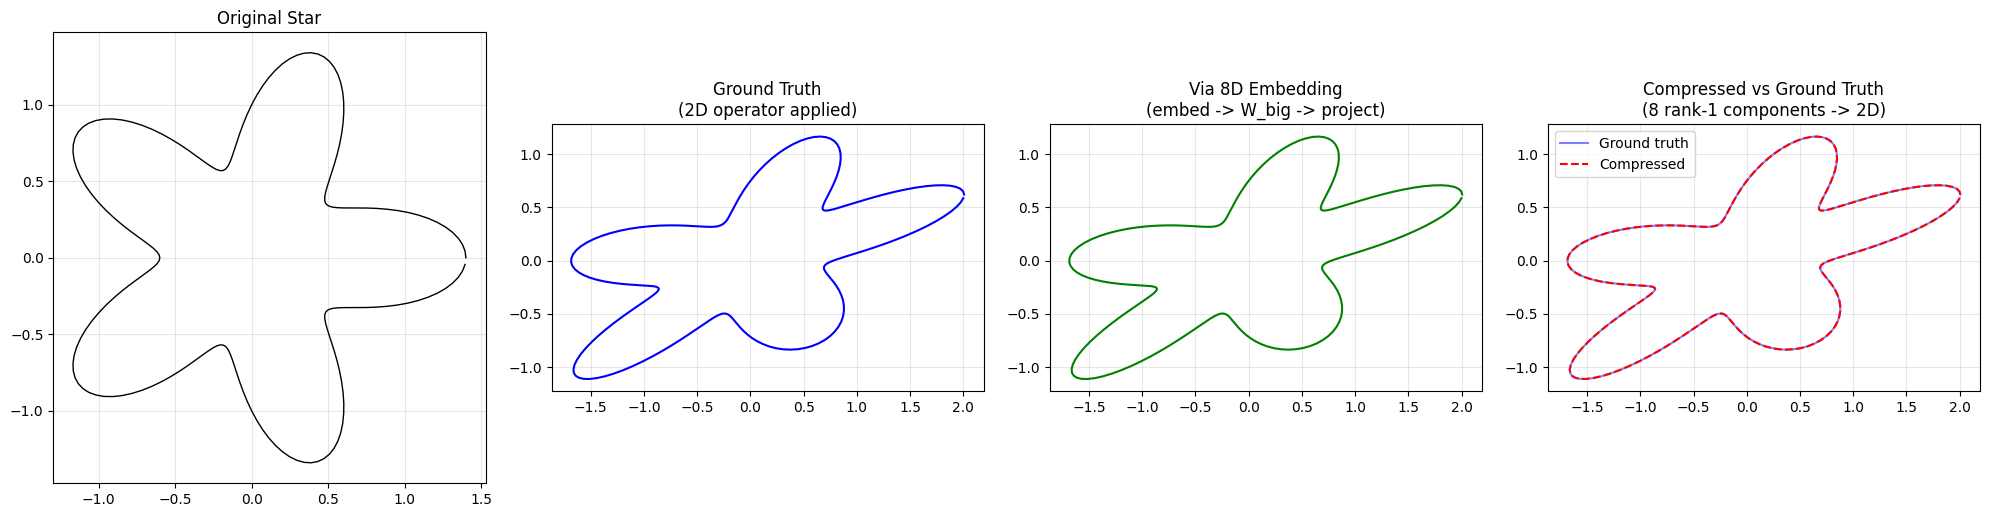

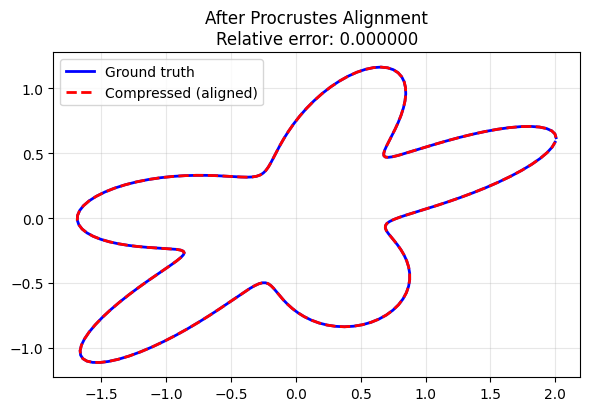

In [15]:
"""
Geometric Compression Demo
============================

Create a known geometric object (a rotation + scaling operator) in
high-dimensional space. Decompose it into rank-1 components along
principal directions. Compress each component into a smaller space
via Procrustes alignment. Reassemble. Compare to the ground truth
operator in the smaller space.

The test: if the compression works, the reassembled small operator
should produce the same transformed geometry as the ground truth
small operator, applied to the same inputs.

We use a 2D shape (a star) as the geometric object we're transforming.
The "teacher" operates in 8D (the 2D shape embedded into 8D).
The "student" operates in 2D directly.
Both should produce the same output shape.
"""

import numpy as np
import matplotlib.pyplot as plt


def make_star(n_points=100):
    """A 2D star shape as a point cloud."""
    t = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
    r = 1.0 + 0.4 * np.cos(5 * t)  # 5-pointed star
    x = r * np.cos(t)
    y = r * np.sin(t)
    return np.stack([x, y], axis=1)  # (n_points, 2)


def make_operator_2d(angle=0.3, scale_x=1.5, scale_y=0.7, shear=0.2):
    """
    A known 2D linear operator: rotate, scale anisotropically, shear.
    This is the ground truth transformation we want to preserve.
    """
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
    S = np.array([[scale_x, shear],
                  [0,       scale_y]])
    return R @ S  # (2, 2)


def embed_operator(W_2d, embed_dim=8, seed=42):
    """
    Embed a 2D operator into a higher-dimensional space.

    Creates an embed_dim x embed_dim operator W_big such that
    when restricted to the 2D subspace where the data lives,
    it performs exactly W_2d, and does other stuff in the
    remaining dimensions.

    Returns:
        W_big: (embed_dim, embed_dim) operator
        P_embed: (embed_dim, 2) embedding matrix (how 2D maps into embed_dim)
        P_project: (2, embed_dim) projection matrix (how to get back to 2D)
    """
    rng = np.random.RandomState(seed)

    # random orthonormal embedding of 2D into embed_dim
    A = rng.randn(embed_dim, 2)
    P_embed, _ = np.linalg.qr(A)  # (embed_dim, 2) orthonormal
    P_embed = P_embed[:, :2]
    P_project = P_embed.T  # (2, embed_dim)

    # build the big operator:
    # in the 2D subspace, it does W_2d
    # in the orthogonal complement, it does something else (rotation + scaling)

    # complement basis
    full_Q, _ = np.linalg.qr(np.hstack([P_embed, rng.randn(embed_dim, embed_dim - 2)]))
    Q_complement = full_Q[:, 2:]  # (embed_dim, embed_dim-2)

    # arbitrary operator in the complement
    W_complement = rng.randn(embed_dim - 2, embed_dim - 2) * 0.5

    # assemble: W_big = P_embed @ W_2d @ P_project + Q_complement @ W_complement @ Q_complement^T
    W_big = P_embed @ W_2d @ P_project + Q_complement @ W_complement @ Q_complement.T

    return W_big, P_embed, P_project


def decompose_rank1(W, directions, scales):
    """
    Decompose W into rank-1 components along given directions.

    Component i = scale_i * (W @ v_i) outer v_i

    Args:
        W: (m, n) matrix
        directions: (k, n) orthonormal directions
        scales: (k,) importance weights

    Returns:
        components: list of (m, n) rank-1 matrices
        residual: (m, n) what's left after removing all components
    """
    k, n = directions.shape
    m = W.shape[0]

    components = []
    reconstructed = np.zeros_like(W)

    for i in range(k):
        v = directions[i]  # (n,)
        Wv = W @ v  # (m,)
        component = np.outer(Wv, v)  # (m, n) rank-1
        components.append(component)
        reconstructed += component

    residual = W - reconstructed
    return components, residual


def procrustes_compress_component(component, P_out, P_in):
    """
    Compress a single rank-1 component from (m, n) to (m', n').

    Args:
        component: (m, n) rank-1 matrix
        P_out: (m', m) output projection
        P_in: (n', n) input projection

    Returns:
        compressed: (m', n') matrix
    """
    return P_out @ component @ P_in.T


def find_optimal_projections(components, scales, m_target, n_target):
    """
    Find P_out and P_in that best preserve the weighted sum of
    rank-1 components when compressed.

    This is the key step: we don't pick directions to discard.
    We find the projections that preserve the total action best
    when all components are summed in the smaller space.

    The weighted reconstruction is: sum_i scale_i * P_out @ comp_i @ P_in^T
    We want this to match the ground truth small operator as closely as possible.

    Since we're doing a demo with known ground truth, we find P_out and P_in
    via SVD of the scale-weighted sum of components (which is just a
    weighted version of W restricted to the important directions).
    """
    m, n = components[0].shape

    # weighted sum
    W_weighted = np.zeros((m, n))
    for comp, s in zip(components, scales):
        W_weighted += s * comp

    # SVD of the weighted operator
    U, S, Vt = np.linalg.svd(W_weighted, full_matrices=True)

    # take top dimensions
    P_out = U[:, :m_target].T  # (m_target, m)
    P_in = Vt[:n_target, :]     # (n_target, n)

    return P_out, P_in


def compress_and_reassemble(components, scales, P_out, P_in):
    """
    Compress each rank-1 component individually, then sum.

    The interference pattern of all components in the smaller
    space determines what survives. Nothing is explicitly discarded.
    """
    m_target = P_out.shape[0]
    n_target = P_in.shape[0]

    W_small = np.zeros((m_target, n_target))

    for comp, s in zip(components, scales):
        compressed = procrustes_compress_component(comp, P_out, P_in)
        W_small += compressed  # unweighted sum: scales are already in the components

    return W_small


def demo():
    # === Ground truth ===
    W_2d = make_operator_2d(angle=0.3, scale_x=1.5, scale_y=0.7, shear=0.2)
    print("Ground truth 2D operator:")
    print(W_2d)
    print()

    # === Embed into 8D ===
    embed_dim = 8
    W_big, P_embed, P_project = embed_operator(W_2d, embed_dim=embed_dim)
    print(f"Embedded into {embed_dim}D operator: {W_big.shape}")

    # verify embedding: P_project @ W_big @ P_embed should recover W_2d
    W_recovered_direct = P_project @ W_big @ P_embed
    print(f"Direct recovery error: {np.linalg.norm(W_recovered_direct - W_2d):.2e}")
    print()

    # === Generate test shape ===
    star = make_star(200)  # (200, 2)

    # === Find principal directions from DATA, not from the operator ===
    # This is what CardHouse actually does: directions come from the
    # activation distribution (X^T X), not from the weight matrix (W^T W).
    # The data tells you which dimensions matter. The operator tells you
    # which dimensions are large. Those aren't the same thing.
    star_8d = star @ P_embed.T  # (n_points, 8) - data in 8D
    XtX = star_8d.T @ star_8d / len(star_8d)  # activation second moment
    eigvals, eigvecs = np.linalg.eigh(XtX)
    # sort descending
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    directions = eigvecs.T  # (8, 8) each row is a direction
    scales = np.sqrt(np.maximum(eigvals, 0))  # activation-based scales

    print("Direction scales:")
    for i, s in enumerate(scales):
        print(f"  direction {i}: scale={s:.4f}")
    print()

    # === Decompose into rank-1 components ===
    components, residual = decompose_rank1(W_big, directions, scales)
    print(f"Decomposed into {len(components)} rank-1 components")
    print(f"Residual norm: {np.linalg.norm(residual):.2e}")

    # verify: sum of components + residual = W_big
    recon = sum(components) + residual
    print(f"Reconstruction error: {np.linalg.norm(recon - W_big):.2e}")
    print()

    # === Compress: 8D -> 2D ===
    m_target, n_target = 2, 2

    P_out, P_in = find_optimal_projections(components, scales, m_target, n_target)

    W_compressed = compress_and_reassemble(components, scales, P_out, P_in)

    print("Compressed 2D operator:")
    print(W_compressed)
    print()
    print("Ground truth 2D operator:")
    print(W_2d)
    print()

    # === Align for comparison ===
    # The compressed operator may be in a different basis than the ground truth.
    # Use Procrustes to find the best rotation/reflection aligning them.
    # If the geometry is preserved, there exists an orthogonal Q such that
    # Q @ W_compressed @ Q^T ≈ W_2d (up to scale)

    # compare via singular values (basis-independent)
    s_compressed = np.linalg.svd(W_compressed, compute_uv=False)
    s_truth = np.linalg.svd(W_2d, compute_uv=False)

    print("Singular values comparison:")
    print(f"  Ground truth: {s_truth}")
    print(f"  Compressed:   {s_compressed}")
    print(f"  Ratio:        {s_compressed / s_truth}")
    print()

    # === Visual test: transform a shape ===

    # ground truth transformation
    star_truth = star @ W_2d.T

    # embed star into 8D, transform, project back
    star_8d = star @ P_embed.T  # (200, 8)
    star_8d_transformed = star_8d @ W_big.T  # (200, 8)
    star_from_8d = star_8d_transformed @ P_project.T  # (200, 2)

    # compress pathway: embed, transform with compressed op via P_in/P_out
    # the compressed operator acts on (P_in @ input) and produces output in P_out space
    star_in_compressed_input = star_8d @ P_in.T  # (200, 2)
    star_compressed_output = star_in_compressed_input @ W_compressed.T  # (200, 2)
    # map back: P_out^T maps from compressed output space to 8D, then project to 2D
    star_from_compressed_8d = star_compressed_output @ P_out  # (200, 8)
    star_from_compressed = star_from_compressed_8d @ P_project.T  # (200, 2)

    # === Plot ===
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    ax = axes[0]
    ax.plot(star[:, 0], star[:, 1], 'k-', linewidth=1)
    ax.set_title('Original Star')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(star_truth[:, 0], star_truth[:, 1], 'b-', linewidth=1.5, label='Ground truth')
    ax.set_title('Ground Truth\n(2D operator applied)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.plot(star_from_8d[:, 0], star_from_8d[:, 1], 'g-', linewidth=1.5, label='Via 8D')
    ax.set_title('Via 8D Embedding\n(embed -> W_big -> project)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.plot(star_truth[:, 0], star_truth[:, 1], 'b-', linewidth=1.5, alpha=0.5, label='Ground truth')
    ax.plot(star_from_compressed[:, 0], star_from_compressed[:, 1], 'r--', linewidth=1.5, label='Compressed')
    ax.set_title('Compressed vs Ground Truth\n(8 rank-1 components -> 2D)')
    ax.set_aspect('equal')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('geometric_compression_demo.png', dpi=150, bbox_inches='tight')
    print("Saved: geometric_compression_demo.png")

    # === Quantitative comparison ===
    # Procrustes alignment of the two output shapes
    # find best orthogonal transform Q such that Q @ compressed ≈ truth
    U_p, _, Vt_p = np.linalg.svd(star_truth.T @ star_from_compressed)
    Q_align = U_p @ Vt_p
    star_aligned = star_from_compressed @ Q_align.T

    alignment_error = np.linalg.norm(star_aligned - star_truth) / np.linalg.norm(star_truth)

    fig2, ax = plt.subplots(figsize=(6, 6))
    ax.plot(star_truth[:, 0], star_truth[:, 1], 'b-', linewidth=2, label='Ground truth')
    ax.plot(star_aligned[:, 0], star_aligned[:, 1], 'r--', linewidth=2, label='Compressed (aligned)')
    ax.set_title(f'After Procrustes Alignment\nRelative error: {alignment_error:.6f}')
    ax.set_aspect('equal')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('geometric_compression_aligned.png', dpi=150, bbox_inches='tight')
    print("Saved: geometric_compression_aligned.png")

    print(f"\nFinal alignment error: {alignment_error:.6f}")
    if alignment_error < 1e-10:
        print("PERFECT compression: geometry fully preserved.")
    elif alignment_error < 0.01:
        print("EXCELLENT compression: geometry nearly perfectly preserved.")
    elif alignment_error < 0.1:
        print("GOOD compression: geometry mostly preserved.")
    else:
        print("POOR compression: significant geometric distortion.")

    return {
        'W_2d': W_2d,
        'W_compressed': W_compressed,
        'alignment_error': alignment_error,
        'singular_values_truth': s_truth,
        'singular_values_compressed': s_compressed,
    }


if __name__ == '__main__':
    results = demo()

HIGH-RANK GEOMETRIC COMPRESSION

Data shape: (500, 8)
Operator shape: (8, 8)
True singular values: [4.  3.2 2.5 1.8 1.3 0.9 0.5 0.3]
Actual singular values: [4.  3.2 2.5 1.8 1.3 0.9 0.5 0.3]

Input shape energy per dim:  [0.5   0.405 0.32  0.245 0.18  0.125 0.08  0.045]
Output shape energy per dim: [2.333  0.5469 0.7639 0.7319 0.4753 0.6707 0.7519 1.2881]

Data direction scales: [0.7071 0.6364 0.5657 0.495  0.4243 0.3536 0.2828 0.2121]
Data eigenvalues:      [0.5   0.405 0.32  0.245 0.18  0.125 0.08  0.045]

────────────────────────────────────────
Compressing 8D -> 2D
────────────────────────────────────────
  Our method error:    0.839873
  Optimal error:       0.535543
  Ratio (ours/optimal): 1.5683
  Energy kept (optimal): 0.7132
  Compressed SVs: [1.9505 1.0139]
  Component contributions:
    dir 0: scale=0.7071, contribution=1.6877
    dir 1: scale=0.6364, contribution=1.4086

────────────────────────────────────────
Compressing 8D -> 3D
────────────────────────────────────────
 

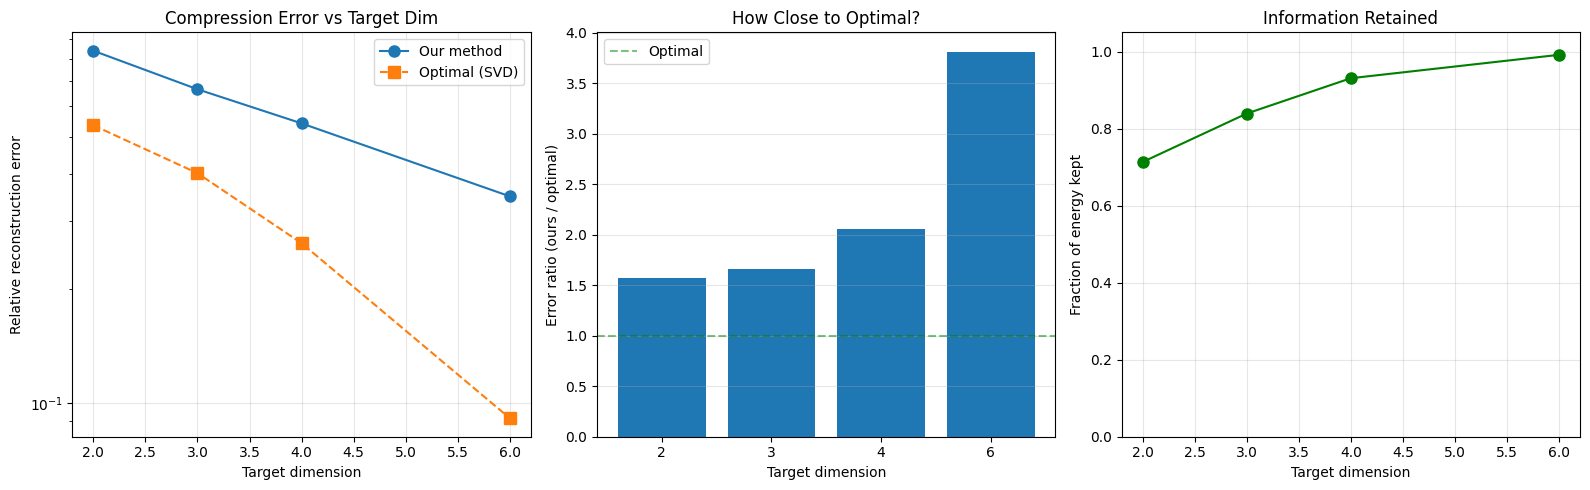

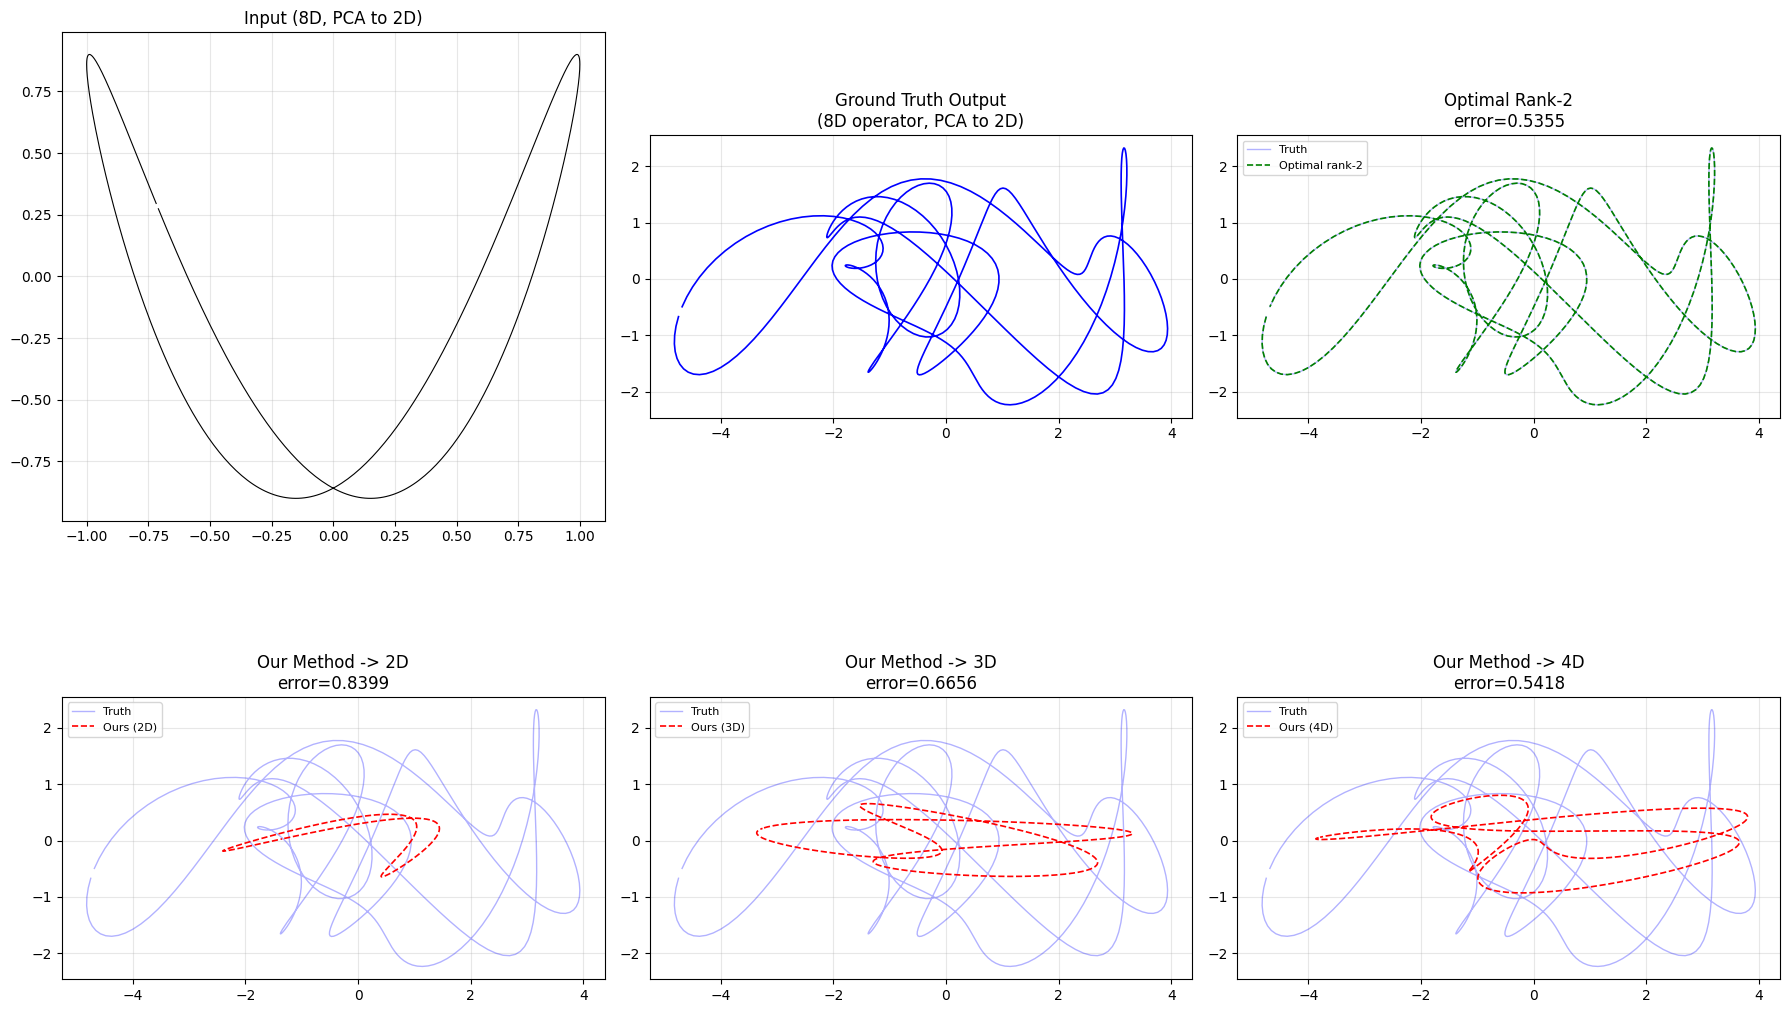

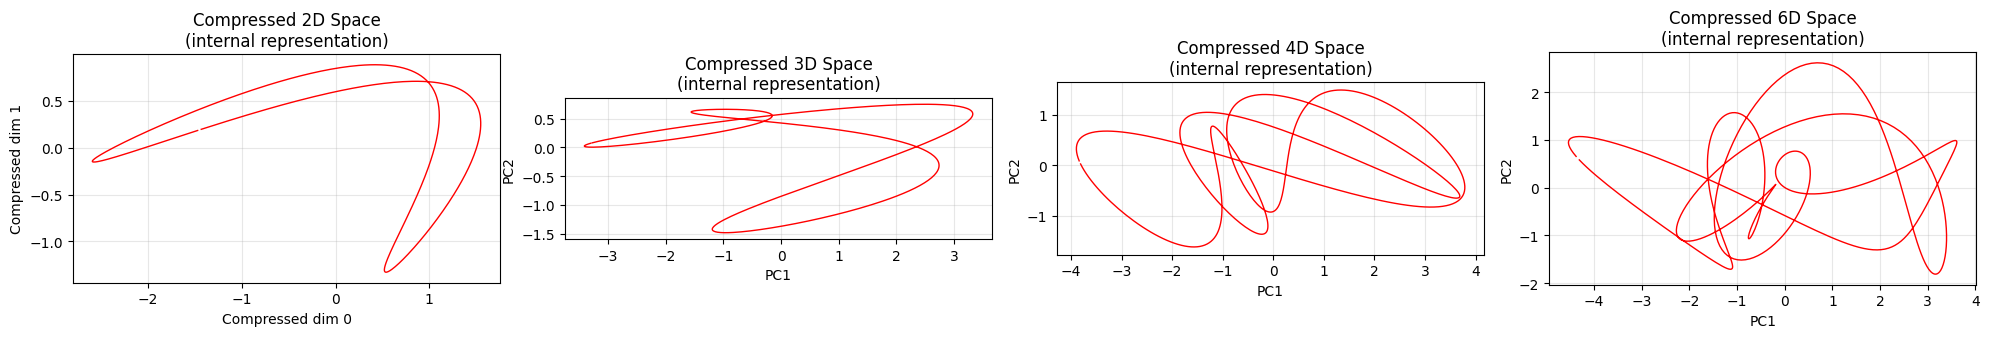

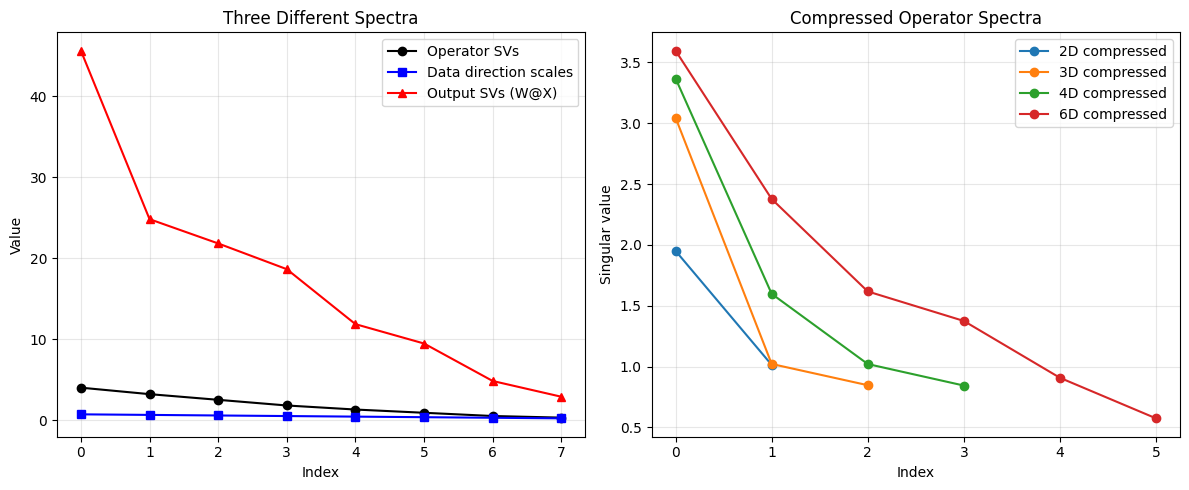

In [11]:
"""
High-Rank Geometric Compression Demo
======================================

Create a geometric operator that genuinely uses all 8 dimensions.
Decompose it into rank-1 components along data-driven directions.
Compress to 2D. Compare against:
  1. The theoretically optimal rank-2 approximation (SVD)
  2. The original 8D transformation viewed through the best 2D projection

The goal: the decompose-and-reassemble method should match or approach
the theoretical optimum, and we should be able to measure exactly
what geometric information survives and what is lost.
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# 1. HIGH-DIMENSIONAL GEOMETRIC OBJECTS
# ============================================================

def make_8d_shape(n_points=500, seed=42):
    """
    A shape that genuinely lives in 8D: a Lissajous-like curve
    with incommensurate frequencies across all 8 axes.
    Every dimension carries unique structure.
    """
    rng = np.random.RandomState(seed)
    t = np.linspace(0, 2 * np.pi, n_points, endpoint=False)

    freqs = [1, 2, 3, 5, 7, 8, 11, 13]  # incommensurate
    phases = rng.uniform(0, 2 * np.pi, 8)
    amplitudes = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]  # decaying but all nonzero

    X = np.zeros((n_points, 8))
    for i in range(8):
        X[:, i] = amplitudes[i] * np.sin(freqs[i] * t + phases[i])

    return X, t


def make_8d_operator(seed=42):
    """
    A full-rank 8x8 operator with known structure:
    rotation + anisotropic scaling + mild shear.
    All 8 singular values are distinct and nonzero.
    """
    rng = np.random.RandomState(seed)

    # random orthogonal matrix (rotation/reflection)
    A = rng.randn(8, 8)
    Q, _ = np.linalg.qr(A)

    # anisotropic scaling with known singular values
    # these decay but are all significant
    singular_values = np.array([4.0, 3.2, 2.5, 1.8, 1.3, 0.9, 0.5, 0.3])

    # another random orthogonal matrix
    B = rng.randn(8, 8)
    U, _ = np.linalg.qr(B)

    # W = U @ diag(S) @ Q^T  (known SVD)
    W = U @ np.diag(singular_values) @ Q.T

    return W, singular_values, U, Q


# ============================================================
# 2. DECOMPOSITION AND COMPRESSION
# ============================================================

def data_driven_directions(X):
    """
    Find principal directions from data distribution.
    Returns directions sorted by variance (descending) and their scales.
    """
    XtX = X.T @ X / len(X)
    eigvals, eigvecs = np.linalg.eigh(XtX)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    directions = eigvecs.T  # (8, 8) rows are directions
    scales = np.sqrt(np.maximum(eigvals, 0))

    return directions, scales, eigvals


def decompose_rank1(W, directions):
    """
    Decompose W into rank-1 components along given directions.
    Component i = (W @ v_i) outer v_i
    """
    components = []
    for i in range(len(directions)):
        v = directions[i]
        Wv = W @ v
        component = np.outer(Wv, v)
        components.append(component)

    residual = W - sum(components)
    return components, residual


def compress_reassemble(W, directions, scales, target_dim):
    """
    Full pipeline:
    1. Decompose W into rank-1 components along data directions
    2. Find optimal projections from data distribution
    3. Compress each component via shared projections
    4. Sum to get compressed operator

    Returns compressed operator and the projections used.
    """
    components, residual = decompose_rank1(W, directions)

    # projections from the data-driven effective weight
    # E = W restricted to data subspace = W @ V^T where V = top directions
    V_top = directions[:target_dim]  # (target_dim, 8)
    E = W @ V_top.T  # (8, target_dim) - how W acts on top data directions

    # SVD of effective weight gives optimal output projection
    U_e, S_e, Vt_e = np.linalg.svd(E, full_matrices=False)

    P_out = U_e[:, :target_dim].T  # (target_dim, 8)
    P_in = V_top  # (target_dim, 8) - data directions ARE the input projection

    # compress each component and sum
    W_compressed = np.zeros((target_dim, target_dim))
    component_contributions = []

    for i, (comp, s) in enumerate(zip(components, scales)):
        compressed_comp = P_out @ comp @ P_in.T
        W_compressed += compressed_comp
        contribution_norm = np.linalg.norm(compressed_comp)
        component_contributions.append({
            'index': i,
            'scale': s,
            'contribution_norm': contribution_norm,
            'compressed_component': compressed_comp,
        })

    return {
        'W_compressed': W_compressed,
        'P_out': P_out,
        'P_in': P_in,
        'components': component_contributions,
        'residual_norm': np.linalg.norm(residual),
    }


def optimal_rank_k(W, X, k):
    """
    Theoretically optimal rank-k approximation of W's action on data X.

    Find the rank-k operator that minimizes ||W @ X^T - W_k @ X^T||_F
    subject to rank(W_k) = k.

    This is the best possible k-dimensional compression. Our method
    should approach this but may not match it exactly.
    """
    # W acting on the data
    Y = W @ X.T  # (8, n_points)

    # SVD of the output
    U_y, S_y, Vt_y = np.linalg.svd(Y, full_matrices=False)

    # best rank-k approximation of Y
    Y_k = U_y[:, :k] @ np.diag(S_y[:k]) @ Vt_y[:k, :]

    # reconstruction error
    full_energy = np.sum(S_y ** 2)
    kept_energy = np.sum(S_y[:k] ** 2)
    lost_energy = full_energy - kept_energy

    return {
        'Y_k': Y_k,
        'Y_full': Y,
        'singular_values': S_y,
        'energy_kept': kept_energy / full_energy,
        'energy_lost': lost_energy / full_energy,
    }


# ============================================================
# 3. VISUALIZATION
# ============================================================

def project_to_2d_for_plotting(X_8d, method='pca'):
    """Project 8D points to 2D for visualization."""
    X_centered = X_8d - X_8d.mean(axis=0)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    return X_centered @ Vt[:2].T, Vt[:2]


def demo():
    print("=" * 60)
    print("HIGH-RANK GEOMETRIC COMPRESSION")
    print("=" * 60)

    # === Create genuine 8D objects ===
    X, t = make_8d_shape(n_points=500)
    W, true_svs, true_U, true_Q = make_8d_operator()

    print(f"\nData shape: {X.shape}")
    print(f"Operator shape: {W.shape}")
    print(f"True singular values: {true_svs}")

    # verify W is full rank
    actual_svs = np.linalg.svd(W, compute_uv=False)
    print(f"Actual singular values: {np.round(actual_svs, 4)}")

    # transform the shape
    Y = X @ W.T  # (500, 8)

    print(f"\nInput shape energy per dim:  {np.round(np.var(X, axis=0), 4)}")
    print(f"Output shape energy per dim: {np.round(np.var(Y, axis=0), 4)}")

    # === Data-driven directions ===
    directions, scales, data_eigvals = data_driven_directions(X)

    print(f"\nData direction scales: {np.round(scales, 4)}")
    print(f"Data eigenvalues:      {np.round(data_eigvals, 4)}")

    # === Compress to various target dimensions ===
    target_dims = [2, 3, 4, 6]
    results = {}

    for td in target_dims:
        print(f"\n{'─' * 40}")
        print(f"Compressing 8D -> {td}D")
        print(f"{'─' * 40}")

        # our method
        comp_result = compress_reassemble(W, directions, scales, td)
        W_comp = comp_result['W_compressed']
        P_out = comp_result['P_out']
        P_in = comp_result['P_in']

        # apply compressed operator to data
        X_in_compressed = X @ P_in.T  # (500, td)
        Y_compressed_space = X_in_compressed @ W_comp.T  # (500, td)
        # map back to 8D for comparison
        Y_reconstructed = Y_compressed_space @ P_out  # (500, 8)

        # theoretical optimum
        opt = optimal_rank_k(W, X, td)
        Y_optimal = opt['Y_k'].T  # (500, 8)

        # errors
        Y_full = Y  # (500, 8) ground truth

        our_error = np.linalg.norm(Y_reconstructed - Y_full) / np.linalg.norm(Y_full)
        opt_error = np.linalg.norm(Y_optimal - Y_full) / np.linalg.norm(Y_full)

        # singular values of compressed operator
        comp_svs = np.linalg.svd(W_comp, compute_uv=False)

        print(f"  Our method error:    {our_error:.6f}")
        print(f"  Optimal error:       {opt_error:.6f}")
        print(f"  Ratio (ours/optimal): {our_error / opt_error:.4f}")
        print(f"  Energy kept (optimal): {opt['energy_kept']:.4f}")
        print(f"  Compressed SVs: {np.round(comp_svs, 4)}")

        # per-component contributions
        print(f"  Component contributions:")
        for cc in comp_result['components']:
            if cc['contribution_norm'] > 1e-10:
                print(f"    dir {cc['index']}: scale={cc['scale']:.4f}, "
                      f"contribution={cc['contribution_norm']:.4f}")

        results[td] = {
            'comp_result': comp_result,
            'our_error': our_error,
            'opt_error': opt_error,
            'Y_reconstructed': Y_reconstructed,
            'Y_optimal': Y_optimal,
            'Y_compressed_space': Y_compressed_space,
            'X_compressed': X_in_compressed,
            'energy_kept': opt['energy_kept'],
            'output_svs': opt['singular_values'],
        }

    # === Plots ===

    # --- Plot 1: compression quality across dimensions ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    ax = axes[0]
    our_errors = [results[td]['our_error'] for td in target_dims]
    opt_errors = [results[td]['opt_error'] for td in target_dims]
    ax.plot(target_dims, our_errors, 'o-', label='Our method', markersize=8)
    ax.plot(target_dims, opt_errors, 's--', label='Optimal (SVD)', markersize=8)
    ax.set_xlabel('Target dimension')
    ax.set_ylabel('Relative reconstruction error')
    ax.set_title('Compression Error vs Target Dim')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    ratios = [results[td]['our_error'] / results[td]['opt_error'] for td in target_dims]
    ax.bar(range(len(target_dims)), ratios, tick_label=[str(d) for d in target_dims])
    ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Optimal')
    ax.set_xlabel('Target dimension')
    ax.set_ylabel('Error ratio (ours / optimal)')
    ax.set_title('How Close to Optimal?')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[2]
    energies = [results[td]['energy_kept'] for td in target_dims]
    ax.plot(target_dims, energies, 'o-', markersize=8, color='green')
    ax.set_xlabel('Target dimension')
    ax.set_ylabel('Fraction of energy kept')
    ax.set_title('Information Retained')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('compression_quality.png', dpi=150, bbox_inches='tight')
    print("\nSaved: compression_quality.png")

    # --- Plot 2: geometric comparison at 2D ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # project everything to 2D via PCA of the full output for consistent viewing
    Y_all = Y
    Y_centered = Y_all - Y_all.mean(axis=0)
    _, _, Vt_view = np.linalg.svd(Y_centered, full_matrices=False)
    proj_view = Vt_view[:2]  # (2, 8)

    # also get input viewing projection
    X_centered = X - X.mean(axis=0)
    _, _, Vt_in = np.linalg.svd(X_centered, full_matrices=False)
    proj_in = Vt_in[:2]

    # input shape
    ax = axes[0, 0]
    X_2d = X @ proj_in.T
    ax.plot(X_2d[:, 0], X_2d[:, 1], 'k-', linewidth=0.8)
    ax.set_title('Input (8D, PCA to 2D)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # ground truth output
    ax = axes[0, 1]
    Y_2d = Y @ proj_view.T
    ax.plot(Y_2d[:, 0], Y_2d[:, 1], 'b-', linewidth=1.2)
    ax.set_title('Ground Truth Output\n(8D operator, PCA to 2D)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # optimal rank-2
    ax = axes[0, 2]
    Y_opt_2d = results[2]['Y_optimal'] @ proj_view.T
    ax.plot(Y_2d[:, 0], Y_2d[:, 1], 'b-', linewidth=1, alpha=0.3, label='Truth')
    ax.plot(Y_opt_2d[:, 0], Y_opt_2d[:, 1], 'g--', linewidth=1.2, label='Optimal rank-2')
    ax.set_title(f'Optimal Rank-2\nerror={results[2]["opt_error"]:.4f}')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # our method at 2D, 3D, 4D
    for i, td in enumerate([2, 3, 4]):
        ax = axes[1, i]
        Y_ours_2d = results[td]['Y_reconstructed'] @ proj_view.T
        ax.plot(Y_2d[:, 0], Y_2d[:, 1], 'b-', linewidth=1, alpha=0.3, label='Truth')
        ax.plot(Y_ours_2d[:, 0], Y_ours_2d[:, 1], 'r--', linewidth=1.2, label=f'Ours ({td}D)')
        ax.set_title(f'Our Method -> {td}D\nerror={results[td]["our_error"]:.4f}')
        ax.set_aspect('equal')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('geometric_comparison.png', dpi=150, bbox_inches='tight')
    print("Saved: geometric_comparison.png")

    # --- Plot 3: what the compressed space looks like ---
    fig, axes = plt.subplots(1, len(target_dims), figsize=(5 * len(target_dims), 5))

    for i, td in enumerate(target_dims):
        ax = axes[i]
        Y_cs = results[td]['Y_compressed_space']
        if td == 2:
            ax.plot(Y_cs[:, 0], Y_cs[:, 1], 'r-', linewidth=1)
            ax.set_xlabel('Compressed dim 0')
            ax.set_ylabel('Compressed dim 1')
        elif td >= 3:
            # project compressed space to 2D
            Y_cs_c = Y_cs - Y_cs.mean(axis=0)
            _, _, Vt_cs = np.linalg.svd(Y_cs_c, full_matrices=False)
            Y_cs_2d = Y_cs_c @ Vt_cs[:2].T
            ax.plot(Y_cs_2d[:, 0], Y_cs_2d[:, 1], 'r-', linewidth=1)
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')
        ax.set_title(f'Compressed {td}D Space\n(internal representation)')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('compressed_spaces.png', dpi=150, bbox_inches='tight')
    print("Saved: compressed_spaces.png")

    # --- Plot 4: singular value story ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(range(8), actual_svs, 'ko-', label='Operator SVs', markersize=6)
    ax.plot(range(8), scales, 'bs-', label='Data direction scales', markersize=6)
    output_svs = results[2]['output_svs']
    ax.plot(range(len(output_svs)), output_svs, 'r^-', label='Output SVs (W@X)', markersize=6)
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Three Different Spectra')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for td in target_dims:
        comp_svs = np.linalg.svd(results[td]['comp_result']['W_compressed'], compute_uv=False)
        ax.plot(range(len(comp_svs)), comp_svs, 'o-', label=f'{td}D compressed', markersize=6)
    ax.set_xlabel('Index')
    ax.set_ylabel('Singular value')
    ax.set_title('Compressed Operator Spectra')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('spectral_story.png', dpi=150, bbox_inches='tight')
    print("Saved: spectral_story.png")

    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    for td in target_dims:
        r = results[td]
        print(f"  {td}D: our_error={r['our_error']:.4f}, "
              f"optimal={r['opt_error']:.4f}, "
              f"ratio={r['our_error']/r['opt_error']:.2f}x, "
              f"energy_kept={r['energy_kept']:.1%}")

    return results


if __name__ == '__main__':
    results = demo()

LEAST-SQUARES GEOMETRIC COMPRESSION

Data: (500, 8), Operator: (8, 8)
True singular values: [4.  3.2 2.5 1.8 1.3 0.9 0.5 0.3]

────────────────────────────────────────
Compressing 8D -> 2D
────────────────────────────────────────
  Least-squares error: 0.839873
  Optimal error:       0.535543
  Ratio (ours/optimal): 1.5683
  Energy kept (optimal): 0.7132
  Compressed SVs: [1.9505 1.0139]

────────────────────────────────────────
Compressing 8D -> 3D
────────────────────────────────────────
  Least-squares error: 0.665630
  Optimal error:       0.401191
  Ratio (ours/optimal): 1.6591
  Energy kept (optimal): 0.8390
  Compressed SVs: [3.0447 1.0216 0.847 ]

────────────────────────────────────────
Compressing 8D -> 4D
────────────────────────────────────────
  Least-squares error: 0.541770
  Optimal error:       0.262891
  Ratio (ours/optimal): 2.0608
  Energy kept (optimal): 0.9309
  Compressed SVs: [3.3673 1.5978 1.021  0.8442]

────────────────────────────────────────
Compressing 8D -

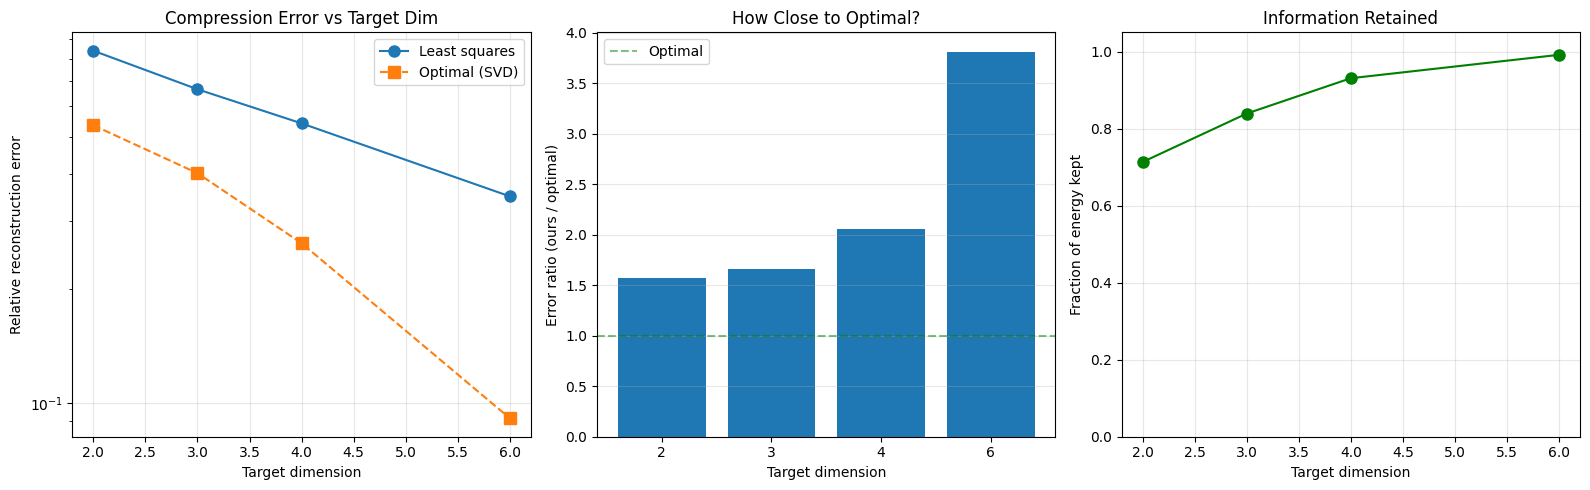

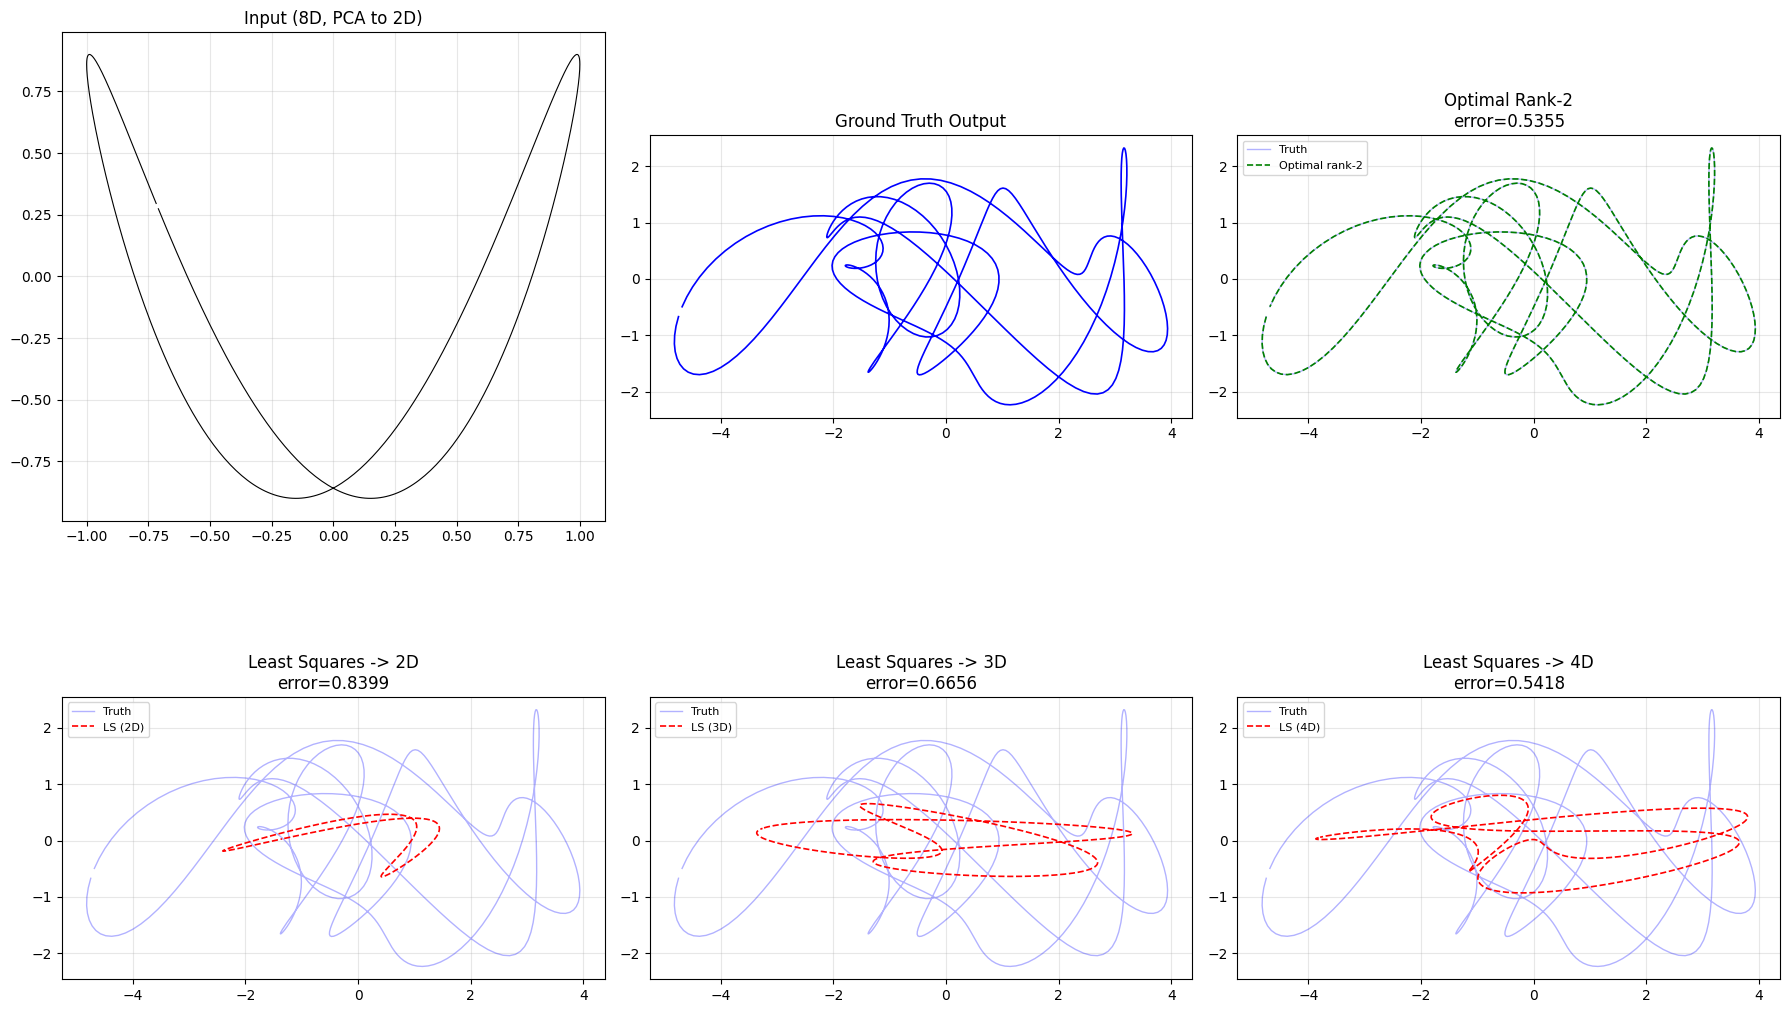

In [12]:
"""
Least-Squares Manifold Compression
====================================

Given a teacher weight matrix W and activation data X, find the
optimal compressed operator W_small that minimizes reconstruction
error of the teacher's input-output mapping in the compressed space.

The projections P_in and P_out come from the data distribution
(activation second moment eigenvectors and effective weight SVD).
Once those are fixed, W_small is solved in closed form via
least squares.

For the neural network case, cross-layer compatibility is handled
by chaining: the output projection of layer l defines the input
subspace of layer l+1.
"""

import numpy as np


# ============================================================
# CORE: DATA-DRIVEN PROJECTIONS + LEAST SQUARES
# ============================================================

def data_driven_directions(X):
    """
    Principal directions from activation data.
    X: (n_samples, dim)
    Returns directions (dim, dim) sorted by variance, scales, eigenvalues.
    """
    XtX = X.T @ X / len(X)
    eigvals, eigvecs = np.linalg.eigh(XtX)
    idx = eigvals.argsort()[::-1]
    return eigvecs[:, idx].T, np.sqrt(np.maximum(eigvals[idx], 0)), eigvals[idx]


def compress_layer_least_squares(W, X, m_target, n_target, P_in_override=None):
    """
    Compress a single layer's weight matrix using least squares.

    Given teacher W (m x n), activation data X (samples x n),
    find W_small (m_target x n_target) that minimizes:

        ||X W^T P_out^T  -  X P_in^T W_small^T||_F^2

    where P_in comes from data directions (or is overridden for
    cross-layer chaining) and P_out comes from SVD of the
    effective weight restricted to the data subspace.

    Args:
        W: (m, n) teacher weight matrix
        X: (samples, n) activation data for this layer
        m_target: student output dimension
        n_target: student input dimension
        P_in_override: if provided, use this as P_in instead of
                       computing from data (for cross-layer chaining)

    Returns:
        W_small: (m_target, n_target) compressed weight
        P_out: (m_target, m) output projection
        P_in: (n_target, n) input projection
        error: relative reconstruction error
    """
    m, n = W.shape

    # --- input projection from data directions ---
    if P_in_override is not None:
        P_in = P_in_override  # (n_target, n)
    else:
        directions, scales, _ = data_driven_directions(X)
        P_in = directions[:n_target]  # (n_target, n)

    # --- output projection from effective weight ---
    # E = W @ P_in^T is the teacher's action on the input subspace
    E = W @ P_in.T  # (m, n_target)
    U_e, S_e, Vt_e = np.linalg.svd(E, full_matrices=False)
    P_out = U_e[:, :m_target].T  # (m_target, m)

    # --- least squares solve ---
    # X_small = X @ P_in^T          (samples, n_target)
    # Y_target = X @ W^T @ P_out^T  (samples, m_target)
    # solve: Y_target = X_small @ W_small^T

    X_small = X @ P_in.T  # (samples, n_target)
    Y_full = X @ W.T  # (samples, m)
    Y_target = Y_full @ P_out.T  # (samples, m_target)

    # W_small^T = (X_small^T X_small)^{-1} X_small^T Y_target
    # use lstsq for numerical stability
    W_small_T, residuals, rank, sv = np.linalg.lstsq(X_small, Y_target, rcond=None)
    W_small = W_small_T.T  # (m_target, n_target)

    # --- reconstruction error ---
    Y_reconstructed = X_small @ W_small.T  # (samples, m_target)
    # map back to full space for comparison
    Y_recon_full = Y_reconstructed @ P_out  # (samples, m)

    error = np.linalg.norm(Y_recon_full - Y_full) / np.linalg.norm(Y_full)

    return {
        'W_small': W_small,
        'P_out': P_out,
        'P_in': P_in,
        'error': error,
    }


def compress_network_least_squares(layer_weights, layer_activations,
                                    target_dims, layer_order):
    """
    Compress an entire network with cross-layer chaining.

    Args:
        layer_weights: dict of layer_name -> (m, n) weight matrix
        layer_activations: dict of layer_name -> (samples, n) activations
        target_dims: dict of layer_name -> (m_target, n_target)
        layer_order: list of layer names in forward order

    Returns:
        compressed: dict of layer_name -> {W_small, P_out, P_in, error}
    """
    compressed = {}
    chain_P_out = None

    for name in layer_order:
        W = layer_weights[name]
        X = layer_activations[name]
        m_target, n_target = target_dims[name]

        # cross-layer chaining: P_out of previous layer constrains P_in
        # of this layer (after elementwise nonlinearity, which doesn't rotate)
        P_in_override = None
        if chain_P_out is not None:
            prev_m_target, prev_m = chain_P_out.shape
            if W.shape[1] == prev_m:
                # use previous P_out as basis for P_in
                if prev_m_target >= n_target:
                    P_in_override = chain_P_out[:n_target]
                else:
                    # need more input dims than previous output dims
                    # take all of chain_P_out, fill rest from data directions
                    directions, _, _ = data_driven_directions(X)
                    extra = []
                    for d in directions:
                        # project out chain_P_out subspace
                        d_orth = d - chain_P_out.T @ (chain_P_out @ d)
                        if np.linalg.norm(d_orth) > 1e-10:
                            extra.append(d_orth / np.linalg.norm(d_orth))
                            if len(extra) + prev_m_target >= n_target:
                                break
                    P_in_override = np.vstack([
                        chain_P_out,
                        np.array(extra)[:n_target - prev_m_target]
                    ])

        result = compress_layer_least_squares(
            W, X, m_target, n_target, P_in_override
        )
        compressed[name] = result
        chain_P_out = result['P_out']

    return compressed


# ============================================================
# BIAS COMPRESSION
# ============================================================

def compress_bias(bias, P_out):
    """Compress bias vector using output projection."""
    if bias is None:
        return None
    return P_out @ bias


# ============================================================
# THEORETICAL OPTIMUM FOR COMPARISON
# ============================================================

def optimal_rank_k(W, X, k):
    """
    Best possible rank-k approximation of W's action on data X.
    Minimizes ||X W^T - Y_k||_F subject to Y_k having rank k.
    """
    Y = X @ W.T
    U_y, S_y, Vt_y = np.linalg.svd(Y, full_matrices=False)
    Y_k = U_y[:, :k] @ np.diag(S_y[:k]) @ Vt_y[:k, :]

    full_energy = np.sum(S_y ** 2)
    kept_energy = np.sum(S_y[:k] ** 2)

    return {
        'Y_k': Y_k,
        'Y_full': Y,
        'singular_values': S_y,
        'energy_kept': kept_energy / full_energy,
        'error': np.linalg.norm(Y_k - Y) / np.linalg.norm(Y),
    }


# ============================================================
# DEMO: HIGH-RANK COMPRESSION TEST
# ============================================================

def make_8d_shape(n_points=500, seed=42):
    rng = np.random.RandomState(seed)
    t = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
    freqs = [1, 2, 3, 5, 7, 8, 11, 13]
    phases = rng.uniform(0, 2 * np.pi, 8)
    amplitudes = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]
    X = np.zeros((n_points, 8))
    for i in range(8):
        X[:, i] = amplitudes[i] * np.sin(freqs[i] * t + phases[i])
    return X, t


def make_8d_operator(seed=42):
    rng = np.random.RandomState(seed)
    A = rng.randn(8, 8)
    Q, _ = np.linalg.qr(A)
    singular_values = np.array([4.0, 3.2, 2.5, 1.8, 1.3, 0.9, 0.5, 0.3])
    B = rng.randn(8, 8)
    U, _ = np.linalg.qr(B)
    W = U @ np.diag(singular_values) @ Q.T
    return W, singular_values


def demo():
    import matplotlib.pyplot as plt

    print("=" * 60)
    print("LEAST-SQUARES GEOMETRIC COMPRESSION")
    print("=" * 60)

    X, t = make_8d_shape(n_points=500)
    W, true_svs = make_8d_operator()
    Y = X @ W.T

    print(f"\nData: {X.shape}, Operator: {W.shape}")
    print(f"True singular values: {true_svs}")

    target_dims = [2, 3, 4, 6]
    results = {}

    for td in target_dims:
        print(f"\n{'─' * 40}")
        print(f"Compressing 8D -> {td}D")
        print(f"{'─' * 40}")

        # our method: least squares
        result = compress_layer_least_squares(W, X, td, td)
        W_comp = result['W_small']
        P_out = result['P_out']
        P_in = result['P_in']

        # apply compressed operator
        X_small = X @ P_in.T
        Y_compressed = X_small @ W_comp.T
        Y_reconstructed = Y_compressed @ P_out

        our_error = np.linalg.norm(Y_reconstructed - Y) / np.linalg.norm(Y)

        # theoretical optimum
        opt = optimal_rank_k(W, X, td)

        # compressed operator spectrum
        comp_svs = np.linalg.svd(W_comp, compute_uv=False)

        print(f"  Least-squares error: {our_error:.6f}")
        print(f"  Optimal error:       {opt['error']:.6f}")
        print(f"  Ratio (ours/optimal): {our_error / opt['error']:.4f}")
        print(f"  Energy kept (optimal): {opt['energy_kept']:.4f}")
        print(f"  Compressed SVs: {np.round(comp_svs, 4)}")

        results[td] = {
            'our_error': our_error,
            'opt_error': opt['error'],
            'Y_reconstructed': Y_reconstructed,
            'Y_optimal': opt['Y_k'],
            'Y_compressed': Y_compressed,
            'energy_kept': opt['energy_kept'],
            'comp_result': result,
        }

    # --- Plots ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    ax = axes[0]
    our_errors = [results[td]['our_error'] for td in target_dims]
    opt_errors = [results[td]['opt_error'] for td in target_dims]
    ax.plot(target_dims, our_errors, 'o-', label='Least squares', markersize=8)
    ax.plot(target_dims, opt_errors, 's--', label='Optimal (SVD)', markersize=8)
    ax.set_xlabel('Target dimension')
    ax.set_ylabel('Relative reconstruction error')
    ax.set_title('Compression Error vs Target Dim')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    ratios = [results[td]['our_error'] / results[td]['opt_error'] for td in target_dims]
    ax.bar(range(len(target_dims)), ratios, tick_label=[str(d) for d in target_dims])
    ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Optimal')
    ax.set_xlabel('Target dimension')
    ax.set_ylabel('Error ratio (ours / optimal)')
    ax.set_title('How Close to Optimal?')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[2]
    energies = [results[td]['energy_kept'] for td in target_dims]
    ax.plot(target_dims, energies, 'o-', markersize=8, color='green')
    ax.set_xlabel('Target dimension')
    ax.set_ylabel('Fraction of energy kept')
    ax.set_title('Information Retained')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('ls_compression_quality.png', dpi=150, bbox_inches='tight')
    print("\nSaved: ls_compression_quality.png")

    # geometric comparison
    Y_centered = Y - Y.mean(axis=0)
    _, _, Vt_view = np.linalg.svd(Y_centered, full_matrices=False)
    proj_view = Vt_view[:2]
    Y_2d = Y @ proj_view.T

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    X_centered = X - X.mean(axis=0)
    _, _, Vt_in = np.linalg.svd(X_centered, full_matrices=False)
    X_2d = X @ Vt_in[:2].T

    ax = axes[0, 0]
    ax.plot(X_2d[:, 0], X_2d[:, 1], 'k-', linewidth=0.8)
    ax.set_title('Input (8D, PCA to 2D)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(Y_2d[:, 0], Y_2d[:, 1], 'b-', linewidth=1.2)
    ax.set_title('Ground Truth Output')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    ax = axes[0, 2]
    Y_opt_2d = results[2]['Y_optimal'] @ proj_view.T
    ax.plot(Y_2d[:, 0], Y_2d[:, 1], 'b-', linewidth=1, alpha=0.3, label='Truth')
    ax.plot(Y_opt_2d[:, 0], Y_opt_2d[:, 1], 'g--', linewidth=1.2, label='Optimal rank-2')
    ax.set_title(f'Optimal Rank-2\nerror={results[2]["opt_error"]:.4f}')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    for i, td in enumerate([2, 3, 4]):
        ax = axes[1, i]
        Y_ours_2d = results[td]['Y_reconstructed'] @ proj_view.T
        ax.plot(Y_2d[:, 0], Y_2d[:, 1], 'b-', linewidth=1, alpha=0.3, label='Truth')
        ax.plot(Y_ours_2d[:, 0], Y_ours_2d[:, 1], 'r--', linewidth=1.2, label=f'LS ({td}D)')
        ax.set_title(f'Least Squares -> {td}D\nerror={results[td]["our_error"]:.4f}')
        ax.set_aspect('equal')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('ls_geometric_comparison.png', dpi=150, bbox_inches='tight')
    print("Saved: ls_geometric_comparison.png")

    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    for td in target_dims:
        r = results[td]
        print(f"  {td}D: our_error={r['our_error']:.4f}, "
              f"optimal={r['opt_error']:.4f}, "
              f"ratio={r['our_error']/r['opt_error']:.2f}x, "
              f"energy_kept={r['energy_kept']:.1%}")

    return results


if __name__ == '__main__':
    results = demo()